## 1. Setup and Imports

In [1]:
# %% Imports
import os
import sys
import json
import importlib
from pathlib import Path
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Add src to path
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'src'))

import data_processing
from config import DATA_PATH

# Reload feature_engineering to pick up any source changes before unpickling
import features.feature_engineering as _fe_module
importlib.reload(_fe_module)
from features.feature_engineering import CarPriceFeatureEngineer

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Project root: {project_root}")
print(f"Data path: {DATA_PATH}")
print("✓ All imports successful")


Project root: /Users/brunobrumbrum/car_price_prediction
Data path: /Users/brunobrumbrum/Documents/data/car_price_prediction
✓ All imports successful


## 2. Load Training Data

Load the original training data for reference and analytics.

In [2]:
# %% Load and Clean Training Data
data_dir = Path(os.path.join(DATA_PATH, "le_boncoin_13_oct_2025"))
print(f"Loading training data from: {data_dir}")

# Load raw data
df_raw = data_processing.load_car_data(data_dir)
print(f"Raw data loaded: {df_raw.shape}")

# Clean data (this renames marque->brand, modele->model, etc.)
df = data_processing.clean_car_data(df_raw)

# Add log_price
df = df.with_columns(
    pl.col('price').log().alias('log_price')
)

print(f"\n✓ Training data loaded and cleaned")
print(f"  Shape: {df.shape}")
print(f"  Year range: {df['year'].min()} - {df['year'].max()}")
print(f"  Unique brands: {df['brand'].n_unique()}")
print(f"  Unique models: {df['model'].n_unique()}")
print(f"\nPrice statistics:")
print(f"  Min: €{df['price'].min():,.0f}")
print(f"  Median: €{df['price'].median():,.0f}")
print(f"  Max: €{df['price'].max():,.0f}")

Loading training data from: /Users/brunobrumbrum/Documents/data/car_price_prediction/le_boncoin_13_oct_2025
📊 Parsing horsepower from puissance_din column...
✅ Loaded 732,427 rows with horsepower parsed
   Note: 'energie' column contains fuel type (kept as-is)
(732427, 36)
Raw data loaded: (732427, 36)
🧹 Starting data cleaning pipeline...

1️⃣ Converting data types and normalizing text...
   Original: 732,427 rows
   After conversion: 732,426 rows
   Removed (invalid price): 1
   Unique brands: 145, Unique models: 1646

2️⃣ Removing antique cars (pre-1990)...
   Removed 14,536 antique cars

3️⃣ Removing 'autre' entries...
   Removed 4,347 'autre' entries

4️⃣ Cleaning horsepower...
   HP cleaning: dropped 5620 cars <50HP, 114 cars >1000HP, 35437 outliers (IQR per brand), 0 missing HP
   Remaining dataset - Mean HP: 139.7, Median HP: 125.0

5️⃣ Dropping rare brands (<400 cars)...
   Dropped 3,805 cars from 65 rare brands (< 400 observations)
   Remaining: 43 brands

6️⃣ Removing price/k

## 3. Load Pre-trained Models

Load the quantile regression models and feature engineer trained in notebook 06.

In [3]:
# %% Load Pre-trained Models
models_dir = project_root / 'models' / 'lean_quantile'

print("=" * 70)
print("LOADING PRE-TRAINED MODELS")
print("=" * 70)
print(f"\nLoading from: {models_dir}")

# Load models
lgb_q15 = joblib.load(models_dir / 'lgb_q15_lean.pkl')
print("✓ Loaded lgb_q15_lean.pkl (15th percentile)")

lgb_q50 = joblib.load(models_dir / 'lgb_q50_lean.pkl')
print("✓ Loaded lgb_q50_lean.pkl (median)")

lgb_q85 = joblib.load(models_dir / 'lgb_q85_lean.pkl')
print("✓ Loaded lgb_q85_lean.pkl (85th percentile)")

# Load feature engineer
feature_engineer = joblib.load(models_dir / 'feature_engineer_lean.pkl')
print("✓ Loaded feature_engineer_lean.pkl")

# Load metadata
with open(models_dir / 'metadata.json', 'r') as f:
    metadata = json.load(f)

print("\n" + "=" * 70)
print("MODEL METADATA")
print("=" * 70)
print(f"Training date: {metadata['training_date']}")
print(f"Number of training samples: {metadata['n_samples']:,}")
print(f"Number of features: {metadata['n_features']}")
print(f"Validation MAE (Q50): {metadata['validation_mae_q50']:.4f}")
print(f"Validation coverage (Q15-Q85): {metadata['validation_coverage']:.2f}%")

# Extract feature columns and brand/model lists
training_feature_cols = metadata['features']['all_features']
all_brands = list(feature_engineer.brand_price_stats_.keys())
all_models = list(feature_engineer.model_price_stats_.keys())

print(f"\n✓ Reference data extracted:")
print(f"  Features: {len(training_feature_cols)}")
print(f"  Known brands: {len(all_brands)}")
print(f"  Known models: {len(all_models)}")

LOADING PRE-TRAINED MODELS

Loading from: /Users/brunobrumbrum/car_price_prediction/models/lean_quantile


✓ Loaded lgb_q15_lean.pkl (15th percentile)
✓ Loaded lgb_q50_lean.pkl (median)
✓ Loaded lgb_q85_lean.pkl (85th percentile)
✓ Loaded feature_engineer_lean.pkl

MODEL METADATA
Training date: 2026-03-13
Number of training samples: 620,918
Number of features: 31
Validation MAE (Q50): 0.1850
Validation coverage (Q15-Q85): 69.81%

✓ Reference data extracted:
  Features: 31
  Known brands: 43
  Known models: 805


## 4. Load Customs Data - Côte d'Ivoire (CI)

Load and clean the customs data from Côte d'Ivoire.

In [4]:
# %% Load Côte d'Ivoire Customs Data
print("=" * 70)
print("LOADING CÔTE D'IVOIRE (CI) CUSTOMS DATA")
print("=" * 70)

# Path to customs Excel file
ci_path = '/Users/brunobrumbrum/Downloads/VEHICULE_CHASSIS (1).xlsx'

df_ci_raw = pl.read_excel(ci_path)
print(f"✓ Loaded {len(df_ci_raw):,} raw records")

# Clean and standardize
df_ci = (
    df_ci_raw
    .with_columns([
        pl.col('MARQUE').str.to_lowercase().str.strip_chars().str.replace('land rover', 'land-rover', literal=True).alias('brand'),
        pl.col('MODELE').str.to_lowercase().str.strip_chars().alias('model'),
        pl.col('PREMIERE_MIS_CIRCULAT').str.slice(0, 4).cast(int).alias('year'),
        (pl.col('VALCAF') * 0.0015).alias('actual_price_eur'),
        pl.lit(100000).alias('km'),  # Dummy km value
        pl.lit('CI').alias('country')  # Country identifier
    ])
    .with_columns([
        # Correct brand names to match training data
        pl.col('brand').replace('land-rover', 'landrover').replace('mercedes-benz', 'mercedesbenz').alias('brand'),
        # Correct model names to match training data
        pl.col('model').replace({
            'cr-v': 'crv',
            'rogue': 'xtrail',
            'mirage': 'space star',
            'glc': 'classe glc',
            'tacoma': 'hilux'
        }).alias('model')
    ])
)

print(f"\n✓ Prepared CI customs data: {len(df_ci):,} vehicles")
print(f"  Year range: {df_ci['year'].min()} - {df_ci['year'].max()}")
print(f"  Unique brands: {df_ci['brand'].n_unique()}")
print(f"  Unique models: {df_ci['model'].n_unique()}")

# Display first 2 rows
print("\nFirst 2 rows:")
df_ci.head(2)

LOADING CÔTE D'IVOIRE (CI) CUSTOMS DATA
✓ Loaded 102 raw records

✓ Prepared CI customs data: 102 vehicles
  Year range: 1992 - 2023
  Unique brands: 30
  Unique models: 55

First 2 rows:


NUMDEC,ANNEE,CHASSIS,PREMIERE_MIS_CIRCULAT,MARQUE,MODELE,PUISSANCE,KILOMETRAGE,PAYS_ORIGINE,VALEURFOB,VALCAF,brand,model,year,actual_price_eur,km,country
str,i64,str,str,str,str,i64,i64,str,i64,i64,str,str,i64,f64,i32,str
"""2024CIAB6C133""",2024,"""WSMS6980000515785""","""1993-01-01 00:00:00.0000000""","""SCHMITZ""","""TRAILER""",null,null,"""Allemagne""",90266,890266,"""schmitz""","""trailer""",1993,1335.399,100000,"""CI"""
"""2024CIAB6C132""",2024,"""VFKTX34CW32FX3348""","""1994-09-01 00:00:00.0000000""","""GENERAL TRAILER""","""LOOSE""",null,null,"""France""",90266,890266,"""general trailer""","""loose""",1994,1335.399,100000,"""CI"""


In [5]:
# %% Filter CI Data to Known Brands/Models
print("=" * 70)
print("FILTERING CI DATA TO KNOWN BRANDS/MODELS")
print("=" * 70)

ci_brands = set(df_ci['brand'].unique().to_list())
ci_models = set(df_ci['model'].unique().to_list())

# Find unseen
unseen_brands_ci = ci_brands - set(all_brands)
unseen_models_ci = ci_models - set(all_models)

print(f"\nBrands: {len(ci_brands)} in data, {len(ci_brands - unseen_brands_ci)} known")
if unseen_brands_ci:
    print(f"  ⚠️ Unseen brands: {sorted(unseen_brands_ci)[:10]}..." if len(unseen_brands_ci) > 10 else f"  ⚠️ Unseen brands: {sorted(unseen_brands_ci)}")
    vehicles_unseen_brands = df_ci.filter(pl.col('brand').is_in(list(unseen_brands_ci))).height
    print(f"     Vehicles affected: {vehicles_unseen_brands:,}")

print(f"\nModels: {len(ci_models)} in data, {len(ci_models - unseen_models_ci)} known")
if unseen_models_ci:
    print(f"  ⚠️ Unseen models: {sorted(unseen_models_ci)[:10]}..." if len(unseen_models_ci) > 10 else f"  ⚠️ Unseen models: {sorted(unseen_models_ci)}")
    vehicles_unseen_models = df_ci.filter(pl.col('model').is_in(list(unseen_models_ci))).height
    print(f"     Vehicles affected: {vehicles_unseen_models:,}")

# Filter to known brands AND models
df_ci_before = len(df_ci)
df_ci_clean = df_ci.filter(
    pl.col('brand').is_in(all_brands) & pl.col('model').is_in(all_models)
)
df_ci_after = len(df_ci_clean)

print(f"\n✓ Filtered: {df_ci_before:,} → {df_ci_after:,} vehicles")
print(f"  Removed: {df_ci_before - df_ci_after:,} vehicles ({(df_ci_before - df_ci_after)/df_ci_before*100:.1f}%)")

FILTERING CI DATA TO KNOWN BRANDS/MODELS

Brands: 30 in data, 14 known
  ⚠️ Unseen brands: ['acura', 'cadillac', 'daf', 'dongfeng', 'fruehauf', 'general trailer', 'great wall', 'howo', 'iribus', 'jetour']...
     Vehicles affected: 34

Models: 55 in data, 29 known
  ⚠️ Unseen models: ['1843', '75', '816 l', 'actros', 'avante', 'axer', 'axor 1845', 'cf', 'cm7', 'dashing']...
     Vehicles affected: 45

✓ Filtered: 102 → 51 vehicles
  Removed: 51 vehicles (50.0%)


<Figure size 1000x600 with 0 Axes>

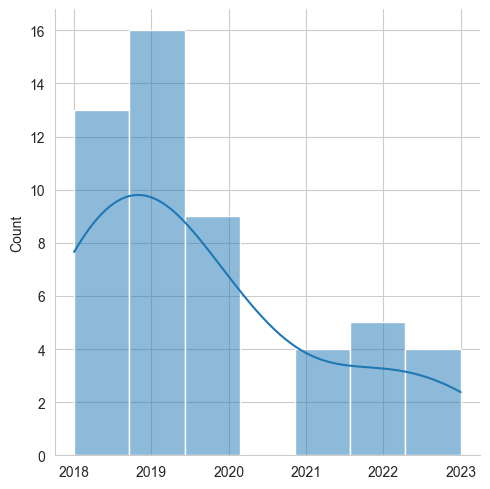

In [6]:
# change to make a bit wider
plt.figure(figsize=(10, 6))
sns.displot(df_ci_clean['year'], kde=True)
plt.show();

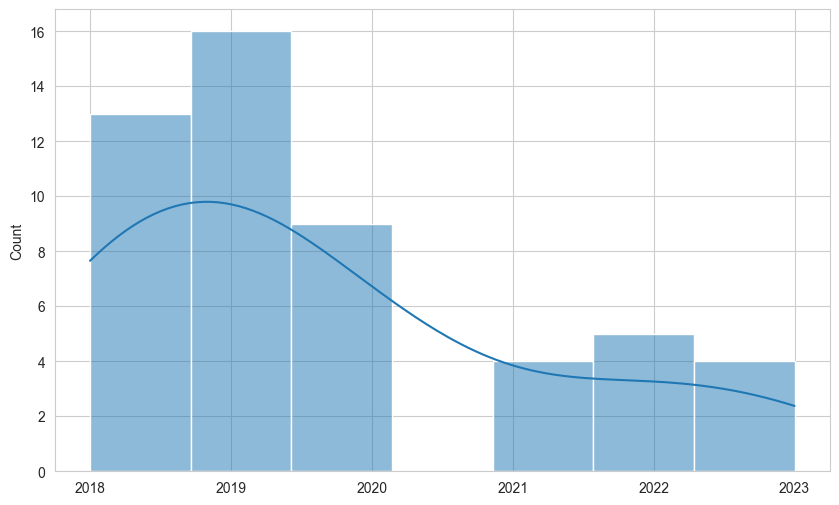

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df_ci_clean['year'], kde=True)
plt.show()

In [8]:
df_ci_clean['brand'].value_counts(sort = True)[10:].to_pandas()

,brand,count
0,chevrolet,1
1,mazda,1
2,peugeot,1
3,citroen,1


There are 9 cars that we are missing, Hyundai 'elantra' and 'sonata', I think because the model that is being saved and loaded is the one only with training data

## 5. Load Customs Data - Cameroon (CM)

Load and clean the customs data from Cameroon.

In [9]:
# %% Load Cameroon Customs Data
print("=" * 70)
print("LOADING CAMEROON (CM) CUSTOMS DATA")
print("=" * 70)

# Path to Cameroon Excel file
cm_path = '/Users/brunobrumbrum/Downloads/Extraction_Jeu_données_Test_Vehicules (2).xlsx'

df_cm_raw = pl.read_excel(cm_path)
print(f"✓ Loaded {len(df_cm_raw):,} raw records")

# Model name corrections specific to Cameroon data
cm_model_corrections = {
    'rav 4': 'rav4',
    'toyota corolla': 'corolla',
    'toyota yaris verso': 'yaris verso',
    'c-max': 'cmax',
    'carina': 'avensis'
}

# Brand corrections specific to Cameroon data
cm_brand_corrections = {
    'land rover': 'landrover'
}

# Clean and standardize
df_cm = (
    df_cm_raw
    .with_columns([
        pl.col('Marque').str.to_lowercase().str.strip_chars().alias('brand'),
        pl.col('Modèle').str.to_lowercase().str.strip_chars().alias('model'),
        pl.col('Année Fabrication').cast(pl.Int64).alias('year'),
        (pl.col('Valeur imposable (XAF)') * 0.0015).alias('actual_price_eur'),
        pl.lit(100000).alias('km'),  # Dummy km value
        pl.lit('CM').alias('country')  # Country identifier
    ])
    .with_columns([
        pl.col('brand').replace(cm_brand_corrections).alias('brand'),
        pl.col('model').replace(cm_model_corrections).alias('model')
    ])
)

print(f"\n✓ Prepared CM customs data: {len(df_cm):,} vehicles")
print(f"  Year range: {df_cm['year'].min()} - {df_cm['year'].max()}")
print(f"  Unique brands: {df_cm['brand'].n_unique()}")
print(f"  Unique models: {df_cm['model'].n_unique()}")

# Display first 2 rows
print("\nFirst 2 rows:")
df_cm.select(['country', 'brand', 'model', 'year', 'actual_price_eur', 'km']).head(2)

LOADING CAMEROON (CM) CUSTOMS DATA
✓ Loaded 50 raw records

✓ Prepared CM customs data: 50 vehicles
  Year range: 1992 - 2017
  Unique brands: 6
  Unique models: 15

First 2 rows:


country,brand,model,year,actual_price_eur,km
str,str,str,i64,f64,i32
"""CM""","""ford""","""cmax""",2005,1410.0,100000
"""CM""","""seat""","""leon""",2007,1438.464,100000


In [10]:
# %% Filter CM Data to Known Brands/Models
print("=" * 70)
print("FILTERING CM DATA TO KNOWN BRANDS/MODELS")
print("=" * 70)

cm_brands = set(df_cm['brand'].unique().to_list())
cm_models = set(df_cm['model'].unique().to_list())

# Find unseen
unseen_brands_cm = cm_brands - set(all_brands)
unseen_models_cm = cm_models - set(all_models)

print(f"\nBrands: {len(cm_brands)} in data, {len(cm_brands - unseen_brands_cm)} known")
if unseen_brands_cm:
    print(f"  ⚠️ Unseen brands: {sorted(unseen_brands_cm)}")
    vehicles_unseen_brands = df_cm.filter(pl.col('brand').is_in(list(unseen_brands_cm))).height
    print(f"     Vehicles affected: {vehicles_unseen_brands:,}")

print(f"\nModels: {len(cm_models)} in data, {len(cm_models - unseen_models_cm)} known")
if unseen_models_cm:
    print(f"  ⚠️ Unseen models: {sorted(unseen_models_cm)}")
    vehicles_unseen_models = df_cm.filter(pl.col('model').is_in(list(unseen_models_cm))).height
    print(f"     Vehicles affected: {vehicles_unseen_models:,}")

# Filter to known brands AND models
df_cm_before = len(df_cm)
df_cm_clean = df_cm.filter(
    pl.col('brand').is_in(all_brands) & pl.col('model').is_in(all_models)
)
df_cm_after = len(df_cm_clean)

print(f"\n✓ Filtered: {df_cm_before:,} → {df_cm_after:,} vehicles")
print(f"  Removed: {df_cm_before - df_cm_after:,} vehicles ({(df_cm_before - df_cm_after)/df_cm_before*100:.1f}%)")

FILTERING CM DATA TO KNOWN BRANDS/MODELS

Brands: 6 in data, 6 known

Models: 15 in data, 11 known
  ⚠️ Unseen models: ['avensis verso', 'carina e', 'previa', 'yaris verso']
     Vehicles affected: 9

✓ Filtered: 50 → 41 vehicles
  Removed: 9 vehicles (18.0%)


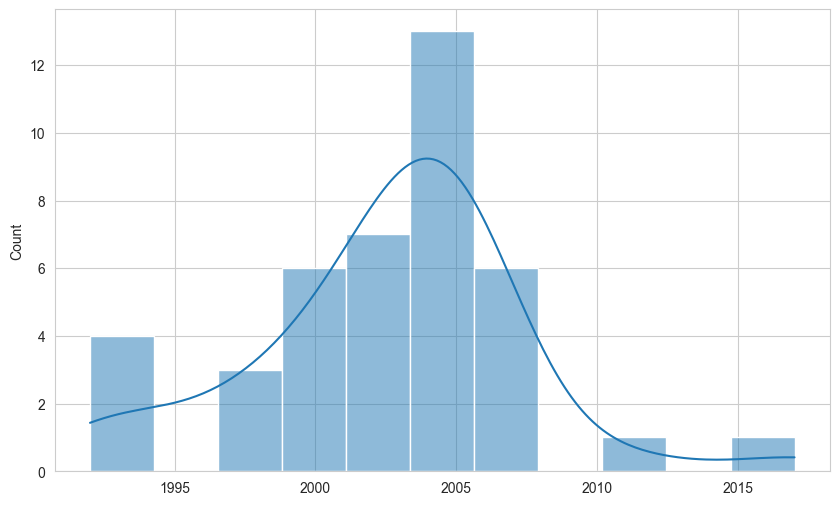

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df_cm_clean['year'], kde=True)
plt.show()

In [12]:
df_cm_clean['brand'].value_counts(sort = True).to_pandas()

,brand,count
0,toyota,36
1,ford,1
2,seat,1
3,landrover,1
4,hyundai,1
5,mitsubishi,1


## 6. Year Distribution Comparison

Compare the year distribution across training data and both customs datasets.

YEAR DISTRIBUTION COMPARISON


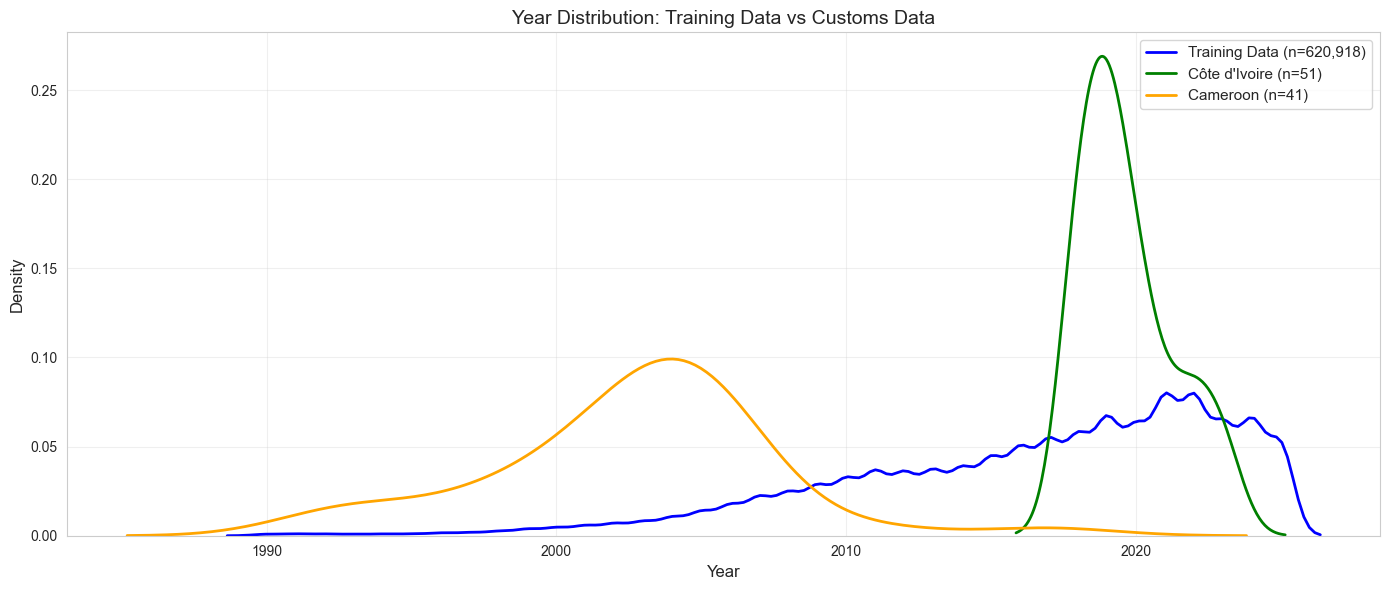


Year Statistics:
Dataset                        Min   Median      Max     Mean
------------------------------------------------------------
Training Data               1990.0     2018   2025.0   2016.5
Côte d'Ivoire (CI)            2018     2019     2023   2019.7
Cameroon (CM)                 1992     2004     2017   2002.6


In [13]:
# %% Year Distribution Comparison
print("=" * 70)
print("YEAR DISTRIBUTION COMPARISON")
print("=" * 70)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot distributions
sns.kdeplot(df['year'].to_numpy(), ax=ax, label=f'Training Data (n={len(df):,})', color='blue', linewidth=2)
sns.kdeplot(df_ci_clean['year'].to_numpy(), ax=ax, label=f'Côte d\'Ivoire (n={len(df_ci_clean):,})', color='green', linewidth=2)
sns.kdeplot(df_cm_clean['year'].to_numpy(), ax=ax, label=f'Cameroon (n={len(df_cm_clean):,})', color='orange', linewidth=2)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Year Distribution: Training Data vs Customs Data', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nYear Statistics:")
print(f"{'Dataset':<25} {'Min':>8} {'Median':>8} {'Max':>8} {'Mean':>8}")
print("-" * 60)
print(f"{'Training Data':<25} {df['year'].min():>8} {df['year'].median():>8.0f} {df['year'].max():>8} {df['year'].mean():>8.1f}")
print(f"{'Côte d\'Ivoire (CI)':<25} {df_ci_clean['year'].min():>8} {df_ci_clean['year'].median():>8.0f} {df_ci_clean['year'].max():>8} {df_ci_clean['year'].mean():>8.1f}")
print(f"{'Cameroon (CM)':<25} {df_cm_clean['year'].min():>8} {df_cm_clean['year'].median():>8.0f} {df_cm_clean['year'].max():>8} {df_cm_clean['year'].mean():>8.1f}")

## 7. Feature Engineering & Predictions

Apply feature engineering and generate predictions for both datasets.

In [14]:
# %% Feature Engineering for CI
print("=" * 70)
print("FEATURE ENGINEERING - CÔTE D'IVOIRE")
print("=" * 70)

# Transform CI data
df_ci_features = feature_engineer.transform(
    df_ci_clean.select(['brand', 'model', 'year', 'km'])
)
print(f"✓ Features generated: {df_ci_features.shape[1]} columns")

# Convert to pandas and align columns
X_ci = df_ci_features.to_pandas()

# Align columns to training feature set
X_ci = X_ci[[c for c in training_feature_cols if c in X_ci.columns]].copy()
for col in training_feature_cols:
    if col not in X_ci.columns:
        X_ci[col] = 0
X_ci = X_ci[training_feature_cols]

# Ensure numeric
for col in X_ci.columns:
    if X_ci[col].dtype == 'object':
        X_ci[col] = pd.to_numeric(X_ci[col], errors='coerce').fillna(0)

print(f"✓ Feature matrix shape: {X_ci.shape}")
print(f"  Columns match training: {list(X_ci.columns) == training_feature_cols}")

FEATURE ENGINEERING - CÔTE D'IVOIRE
✓ Features generated: 54 columns
✓ Feature matrix shape: (51, 31)
  Columns match training: True


In [15]:
# %% Feature Engineering for CM
print("=" * 70)
print("FEATURE ENGINEERING - CAMEROON")
print("=" * 70)

# Transform CM data
df_cm_features = feature_engineer.transform(
    df_cm_clean.select(['brand', 'model', 'year', 'km'])
)
print(f"✓ Features generated: {df_cm_features.shape[1]} columns")

# Convert to pandas and align columns
X_cm = df_cm_features.to_pandas()

# Align columns to training feature set
X_cm = X_cm[[c for c in training_feature_cols if c in X_cm.columns]].copy()
for col in training_feature_cols:
    if col not in X_cm.columns:
        X_cm[col] = 0
X_cm = X_cm[training_feature_cols]

# Ensure numeric
for col in X_cm.columns:
    if X_cm[col].dtype == 'object':
        X_cm[col] = pd.to_numeric(X_cm[col], errors='coerce').fillna(0)

print(f"✓ Feature matrix shape: {X_cm.shape}")
print(f"  Columns match training: {list(X_cm.columns) == training_feature_cols}")

FEATURE ENGINEERING - CAMEROON
✓ Features generated: 54 columns
✓ Feature matrix shape: (41, 31)
  Columns match training: True


In [16]:
# %% Generate Predictions
print("=" * 70)
print("GENERATING PREDICTIONS")
print("=" * 70)

# Predictions for CI (in log space, then convert to EUR)
pred_ci_q15 = np.exp(lgb_q15.predict(X_ci))
pred_ci_q50 = np.exp(lgb_q50.predict(X_ci))
pred_ci_q85 = np.exp(lgb_q85.predict(X_ci))
print(f"✓ CI predictions: {len(pred_ci_q50):,} vehicles")

# Predictions for CM (in log space, then convert to EUR)
pred_cm_q15 = np.exp(lgb_q15.predict(X_cm))
pred_cm_q50 = np.exp(lgb_q50.predict(X_cm))
pred_cm_q85 = np.exp(lgb_q85.predict(X_cm))
print(f"✓ CM predictions: {len(pred_cm_q50):,} vehicles")

# Add predictions to dataframes
df_ci_results = df_ci_clean.with_columns([
    pl.Series('pred_q15', pred_ci_q15),
    pl.Series('pred_q50', pred_ci_q50),
    pl.Series('pred_q85', pred_ci_q85),
    pl.Series('residual', df_ci_clean['actual_price_eur'].to_numpy() - pred_ci_q50),
    pl.Series('pct_error', (df_ci_clean['actual_price_eur'].to_numpy() - pred_ci_q50) / pred_ci_q50 * 100)
])

df_cm_results = df_cm_clean.with_columns([
    pl.Series('pred_q15', pred_cm_q15),
    pl.Series('pred_q50', pred_cm_q50),
    pl.Series('pred_q85', pred_cm_q85),
    pl.Series('residual', df_cm_clean['actual_price_eur'].to_numpy() - pred_cm_q50),
    pl.Series('pct_error', (df_cm_clean['actual_price_eur'].to_numpy() - pred_cm_q50) / pred_cm_q50 * 100)
])

print("\n✓ Predictions added to result dataframes")

GENERATING PREDICTIONS
✓ CI predictions: 51 vehicles
✓ CM predictions: 41 vehicles

✓ Predictions added to result dataframes


In [17]:
# %% Combine Results
print("=" * 70)
print("COMBINING RESULTS")
print("=" * 70)

# Select common columns for joining
common_cols = ['country', 'brand', 'model', 'year', 'actual_price_eur', 
               'pred_q15', 'pred_q50', 'pred_q85', 'residual', 'pct_error']

df_combined = pl.concat([
    df_ci_results.select(common_cols),
    df_cm_results.select(common_cols)
])

print(f"\n✓ Combined dataset: {len(df_combined):,} vehicles")
print(f"  CI: {df_combined.filter(pl.col('country') == 'CI').height:,}")
print(f"  CM: {df_combined.filter(pl.col('country') == 'CM').height:,}")

df_combined.head(5)

COMBINING RESULTS

✓ Combined dataset: 92 vehicles
  CI: 51
  CM: 41


country,brand,model,year,actual_price_eur,pred_q15,pred_q50,pred_q85,residual,pct_error
str,str,str,i64,f64,f64,f64,f64,f64,f64
"""CI""","""landrover""","""range rover""",2023,109106.34,100351.058373,124527.084938,144714.128254,-15420.744938,-12.383446
"""CI""","""toyota""","""hilux""",2020,14702.283,28599.969131,33827.566772,40861.922388,-19125.283772,-56.537569
"""CI""","""mitsubishi""","""pajero""",2020,15601.3155,23458.569859,30223.821652,33553.160097,-14622.506152,-48.380732
"""CI""","""honda""","""crv""",2019,9078.825,19825.259272,22805.850357,25420.859834,-13727.025357,-60.190807
"""CI""","""toyota""","""highlander""",2018,12580.4355,48510.637549,41965.14532,48858.554097,-29384.70982,-70.021704


## 8. Performance Metrics by Country

Calculate and compare model performance metrics for each country.

In [18]:
# %% Performance Metrics by Country
print("=" * 70)
print("PERFORMANCE METRICS BY COUNTRY")
print("=" * 70)

def calculate_metrics(actual, pred_q15, pred_q50, pred_q85):
    """Calculate comprehensive metrics."""
    mae = mean_absolute_error(actual, pred_q50)
    rmse = np.sqrt(mean_squared_error(actual, pred_q50))
    mape = np.mean(np.abs((actual - pred_q50) / actual)) * 100
    r2 = r2_score(actual, pred_q50)
    
    # Coverage: % of actual values within Q15-Q85 interval
    coverage = np.mean((actual >= pred_q15) & (actual <= pred_q85)) * 100
    
    # Mean interval width
    interval_width = np.mean(pred_q85 - pred_q15)
    
    return {
        'MAE (€)': mae,
        'RMSE (€)': rmse,
        'MAPE (%)': mape,
        'R²': r2,
        'Coverage Q15-Q85 (%)': coverage,
        'Avg Interval Width (€)': interval_width
    }

# Calculate metrics for each country
metrics_ci = calculate_metrics(
    df_ci_results['actual_price_eur'].to_numpy(),
    pred_ci_q15, pred_ci_q50, pred_ci_q85
)

metrics_cm = calculate_metrics(
    df_cm_results['actual_price_eur'].to_numpy(),
    pred_cm_q15, pred_cm_q50, pred_cm_q85
)

# Create metrics dataframe
metrics_df = pd.DataFrame({
    'Metric': list(metrics_ci.keys()),
    'Côte d\'Ivoire (CI)': list(metrics_ci.values()),
    'Cameroon (CM)': list(metrics_cm.values())
})

## Format for display
#print("\n" + "=" * 70)
#print(f"{'Metric':<25} {'CI':>20} {'CM':>20}")
#print("=" * 70)
#print(f"{'MAE (€)':<25} {metrics_ci['MAE (€)']:>20,.0f} {metrics_cm['MAE (€)']:>20,.0f}")
#print(f"{'RMSE (€)':<25} {metrics_ci['RMSE (€)']:>20,.0f} {metrics_cm['RMSE (€)']:>20,.0f}")
#print(f"{'MAPE (%)':<25} {metrics_ci['MAPE (%)']:>20.1f} {metrics_cm['MAPE (%)']:>20.1f}")
#print(f"{'R²':<25} {metrics_ci['R²']:>20.3f} {metrics_cm['R²']:>20.3f}")
#print(f"{'Coverage Q15-Q85 (%)':<25} {metrics_ci['Coverage Q15-Q85 (%)']:>20.1f} {metrics_cm['Coverage Q15-Q85 (%)']:>20.1f}")
#print(f"{'Avg Interval Width (€)':<25} {metrics_ci['Avg Interval Width (€)']:>20,.0f} {metrics_cm['Avg Interval Width (€)']:>20,.0f}")
#print("=" * 70)

# Display as styled dataframe
display(metrics_df.round(2))

# Add price descriptive statistics
print("\n" + "=" * 70)
print("PRICE DESCRIPTIVE STATISTICS")
print("=" * 70)

price_stats = pd.DataFrame({
    'Metric': ['Count', 'Mean (€)', 'Median (€)', 'Std Dev (€)', 'Min (€)', '25th Percentile (€)', '75th Percentile (€)', 'Max (€)'],
    'Côte d\'Ivoire (CI)': [
        len(df_ci_results),
        df_ci_results['actual_price_eur'].mean(),
        df_ci_results['actual_price_eur'].median(),
        df_ci_results['actual_price_eur'].std(),
        df_ci_results['actual_price_eur'].min(),
        df_ci_results['actual_price_eur'].quantile(0.25),
        df_ci_results['actual_price_eur'].quantile(0.75),
        df_ci_results['actual_price_eur'].max()
    ],
    'Cameroon (CM)': [
        len(df_cm_results),
        df_cm_results['actual_price_eur'].mean(),
        df_cm_results['actual_price_eur'].median(),
        df_cm_results['actual_price_eur'].std(),
        df_cm_results['actual_price_eur'].min(),
        df_cm_results['actual_price_eur'].quantile(0.25),
        df_cm_results['actual_price_eur'].quantile(0.75),
        df_cm_results['actual_price_eur'].max()
    ]
})

display(price_stats.round(0))

PERFORMANCE METRICS BY COUNTRY


,Metric,Côte d'Ivoire (CI),Cameroon (CM)
0,MAE (€),12978.96,2991.06
1,RMSE (€),15692.57,3336.69
2,MAPE (%),100.74,210.61
3,R²,-0.04,-6.64
4,Coverage Q15-Q85 (%),7.84,2.44
5,Avg Interval Width (€),8272.81,3668.45



PRICE DESCRIPTIVE STATISTICS


,Metric,Côte d'Ivoire (CI),Cameroon (CM)
0,Count,51.0,41.0
1,Mean (€),15333.0,1650.0
2,Median (€),11081.0,1260.0
3,Std Dev (€),15533.0,1222.0
4,Min (€),5484.0,960.0
5,25th Percentile (€),8513.0,1146.0
6,75th Percentile (€),15601.0,1410.0
7,Max (€),109106.0,8314.0


## 8.5 Training Data Match Analysis

For each vehicle in CI and CM, count how many similar vehicles exist in the training data.

In [19]:
# %% Similarity Analysis: Count Training Data Matches
print("=" * 70)
print("SIMILARITY ANALYSIS: TRAINING DATA MATCHES")
print("=" * 70)

# Define year flexibility for matching (±3 years)
year_flex = 1

def count_training_matches(customs_df, training_df, country_name, year_flex=3):
    """
    Count how many similar cars exist in training data for each customs vehicle.
    
    Returns:
    - DataFrame with match counts for each vehicle
    - Summary statistics
    """
    results = []
    
    for row in customs_df.iter_rows(named=True):
        brand = row['brand']
        model = row['model']
        year = row['year']
        
        # Match 1: Exact brand + model + year
        exact_match = training_df.filter(
            (pl.col('brand') == brand) & 
            (pl.col('model') == model) & 
            (pl.col('year') == year)
        ).height
        
        # Match 2: Brand + model + year ±year_flex
        year_flex_match = training_df.filter(
            (pl.col('brand') == brand) & 
            (pl.col('model') == model) & 
            (pl.col('year') >= year - year_flex) & 
            (pl.col('year') <= year + year_flex)
        ).height
        
        results.append({
            'country': country_name,
            'brand': brand,
            'model': model,
            'year': year,
            'actual_price_eur': row['actual_price_eur'],
            'exact_match': exact_match,
            'brand_model_year_flex': year_flex_match
        })
    
    return pl.DataFrame(results)

# Analyze CI data
print("\n🇨🇮 CÔTE D'IVOIRE (CI) - Matching Analysis")
print("-" * 70)
df_ci_matches = count_training_matches(df_ci_clean, df, 'CI', year_flex=year_flex)

print(f"\nSample of matches (first 5 vehicles):")
display(df_ci_matches.head(5))

# Summary statistics for CI
print("\n📊 CI Summary Statistics:")
print(f"{'Brand+Model+Year±' + str(year_flex):<30} {df_ci_matches['brand_model_year_flex'].mean():>10.1f} {df_ci_matches['brand_model_year_flex'].median():>10.0f} {df_ci_matches['brand_model_year_flex'].min():>10,} {df_ci_matches['brand_model_year_flex'].max():>10,}")
print("-" * 70)
print(f"{'Exact (brand+model+year)':<30} {df_ci_matches['exact_match'].mean():>10.1f} {df_ci_matches['exact_match'].median():>10.0f} {df_ci_matches['exact_match'].min():>10,} {df_ci_matches['exact_match'].max():>10,}")
print(f"{'Brand+Model+Year±' + str(year_flex):<30} {df_ci_matches['brand_model_year_flex'].mean():>10.1f} {df_ci_matches['brand_model_year_flex'].median():>10.0f} {df_ci_matches['brand_model_year_flex'].min():>10,} {df_ci_matches['brand_model_year_flex'].max():>10,}")

# Count vehicles with zero matches
zero_exact = (df_ci_matches['exact_match'] == 0).sum()
zero_flex = (df_ci_matches['brand_model_year_flex'] == 0).sum()
print(f"\n⚠️  Vehicles with 0 exact matches: {zero_exact} ({zero_exact/len(df_ci_matches)*100:.1f}%)")
print(f"⚠️  Vehicles with 0 flexible matches: {zero_flex} ({zero_flex/len(df_ci_matches)*100:.1f}%)")

df_cm_matches = count_training_matches(df_cm_clean, df, 'CM', year_flex=year_flex)
print("\n\n🇨🇲 CAMEROON (CM) - Matching Analysis")
print("-" * 70)
df_cm_matches = count_training_matches(df_cm_clean, df, 'CM')

print(f"\nSample of matches (first 5 vehicles):")
display(df_cm_matches.head(5))

# Summary statistics for CM
print("\n📊 CM Summary Statistics:")
print(f"{'Brand+Model+Year±' + str(year_flex):<30} {df_cm_matches['brand_model_year_flex'].mean():>10.1f} {df_cm_matches['brand_model_year_flex'].median():>10.0f} {df_cm_matches['brand_model_year_flex'].min():>10,} {df_cm_matches['brand_model_year_flex'].max():>10,}")
print("-" * 70)
print(f"{'Exact (brand+model+year)':<30} {df_cm_matches['exact_match'].mean():>10.1f} {df_cm_matches['exact_match'].median():>10.0f} {df_cm_matches['exact_match'].min():>10,} {df_cm_matches['exact_match'].max():>10,}")
print(f"{'Brand+Model+Year±' + str(year_flex):<30} {df_cm_matches['brand_model_year_flex'].mean():>10.1f} {df_cm_matches['brand_model_year_flex'].median():>10.0f} {df_cm_matches['brand_model_year_flex'].min():>10,} {df_cm_matches['brand_model_year_flex'].max():>10,}")

# Count vehicles with zero matches
zero_exact = (df_cm_matches['exact_match'] == 0).sum()
zero_flex = (df_cm_matches['brand_model_year_flex'] == 0).sum()
print(f"\n⚠️  Vehicles with 0 exact matches: {zero_exact} ({zero_exact/len(df_cm_matches)*100:.1f}%)")
print(f"⚠️  Vehicles with 0 flexible matches: {zero_flex} ({zero_flex/len(df_cm_matches)*100:.1f}%)")

# Combine for comparison
df_all_matches = pl.concat([df_ci_matches, df_cm_matches])

# Define match types for detailed breakdown
match_types = [
    ('exact_match', 'Exact Match\n(Brand + Model + Year)'),
    ('brand_model_year_flex', f'Flexible Match\n(Brand + Model + Year±{year_flex})')
]

SIMILARITY ANALYSIS: TRAINING DATA MATCHES

🇨🇮 CÔTE D'IVOIRE (CI) - Matching Analysis
----------------------------------------------------------------------

Sample of matches (first 5 vehicles):


country,brand,model,year,actual_price_eur,exact_match,brand_model_year_flex
str,str,str,i64,f64,i64,i64
"""CI""","""landrover""","""range rover""",2023,109106.34,56,121
"""CI""","""toyota""","""hilux""",2020,14702.283,22,71
"""CI""","""mitsubishi""","""pajero""",2020,15601.3155,0,0
"""CI""","""honda""","""crv""",2019,9078.825,22,39
"""CI""","""toyota""","""highlander""",2018,12580.4355,0,0



📊 CI Summary Statistics:
Brand+Model+Year±1                  338.3        121          0      4,005
----------------------------------------------------------------------
Exact (brand+model+year)            108.7         31          0      1,176
Brand+Model+Year±1                  338.3        121          0      4,005

⚠️  Vehicles with 0 exact matches: 5 (9.8%)
⚠️  Vehicles with 0 flexible matches: 5 (9.8%)


🇨🇲 CAMEROON (CM) - Matching Analysis
----------------------------------------------------------------------

Sample of matches (first 5 vehicles):


country,brand,model,year,actual_price_eur,exact_match,brand_model_year_flex
str,str,str,i64,f64,i64,i64
"""CM""","""ford""","""cmax""",2005,1410.0,18,201
"""CM""","""seat""","""leon""",2007,1438.464,68,366
"""CM""","""toyota""","""yaris""",2004,1260.0,24,246
"""CM""","""toyota""","""yaris""",2002,1146.0,12,82
"""CM""","""toyota""","""yaris""",2006,1260.0,74,411



📊 CM Summary Statistics:
Brand+Model+Year±1                  113.2         57          0        663
----------------------------------------------------------------------
Exact (brand+model+year)             13.5          8          0         74
Brand+Model+Year±1                  113.2         57          0        663

⚠️  Vehicles with 0 exact matches: 8 (19.5%)
⚠️  Vehicles with 0 flexible matches: 2 (4.9%)


In [20]:
df_cm_matches.unique().head(10)

country,brand,model,year,actual_price_eur,exact_match,brand_model_year_flex
str,str,str,i64,f64,i64,i64
"""CM""","""toyota""","""corolla""",2002,1314.0,8,41
"""CM""","""toyota""","""avensis""",1994,1260.0,0,0
"""CM""","""toyota""","""corolla""",2003,1146.0,7,52
"""CM""","""toyota""","""avensis""",2004,1410.0,5,31
"""CM""","""toyota""","""rav4""",2005,2490.0,25,205
"""CM""","""toyota""","""corolla""",2006,1829.112,12,44
"""CM""","""ford""","""cmax""",2005,1410.0,18,201
"""CM""","""toyota""","""corolla""",2005,1410.0,9,52
"""CM""","""toyota""","""avensis""",1999,1260.0,1,1


In [21]:
# %% Detailed Breakdown: Vehicles by Match Count Ranges
print("\n" + "=" * 70)
print("DETAILED BREAKDOWN: DISTRIBUTION BY MATCH COUNT RANGES")
print("=" * 70)

def print_match_distribution(df_matches, country_name, match_col, match_name):
    """Print distribution of vehicles across match count ranges."""
    print(f"\n{country_name} - {match_name}")
    print("-" * 60)
    
    counts = df_matches[match_col].to_numpy()
    total = len(counts)
    
    bins = [0, 1, 10, 50, 100, 500, 1000, np.inf]
    labels = ['0', '1-9', '10-49', '50-99', '100-499', '500-999', '1000+']
    
    print(f"{'Range':<15} {'Vehicles':>12} {'%':>8}")
    print("-" * 36)
    
    for i in range(len(bins)-1):
        lower = bins[i]
        upper = bins[i+1]
        
        if upper == np.inf:
            mask = counts >= lower
        else:
            mask = (counts >= lower) & (counts < upper)
        
        count = mask.sum()
        pct = (count / total) * 100
        print(f"{labels[i]:<15} {count:>12,} {pct:>7.1f}%")

# Print distributions for CI
print("\n🇨🇮 CÔTE D'IVOIRE")
for col, name in match_types:
    print_match_distribution(df_ci_matches, 'CI', col, name)

# Print distributions for CM
print("\n\n🇨🇲 CAMEROON")
for col, name in match_types:
    print_match_distribution(df_cm_matches, 'CM', col, name)


DETAILED BREAKDOWN: DISTRIBUTION BY MATCH COUNT RANGES

🇨🇮 CÔTE D'IVOIRE

CI - Exact Match
(Brand + Model + Year)
------------------------------------------------------------
Range               Vehicles        %
------------------------------------
0                          5     9.8%
1-9                       10    19.6%
10-49                     14    27.5%
50-99                      8    15.7%
100-499                   12    23.5%
500-999                    1     2.0%
1000+                      1     2.0%

CI - Flexible Match
(Brand + Model + Year±1)
------------------------------------------------------------
Range               Vehicles        %
------------------------------------
0                          5     9.8%
1-9                        3     5.9%
10-49                     11    21.6%
50-99                      4     7.8%
100-499                   18    35.3%
500-999                    6    11.8%
1000+                      4     7.8%


🇨🇲 CAMEROON

CM - Exact Match
(Br

## 9. Visualization: Actual vs Predicted Price

Scatter plot showing actual vs predicted prices with confidence intervals.

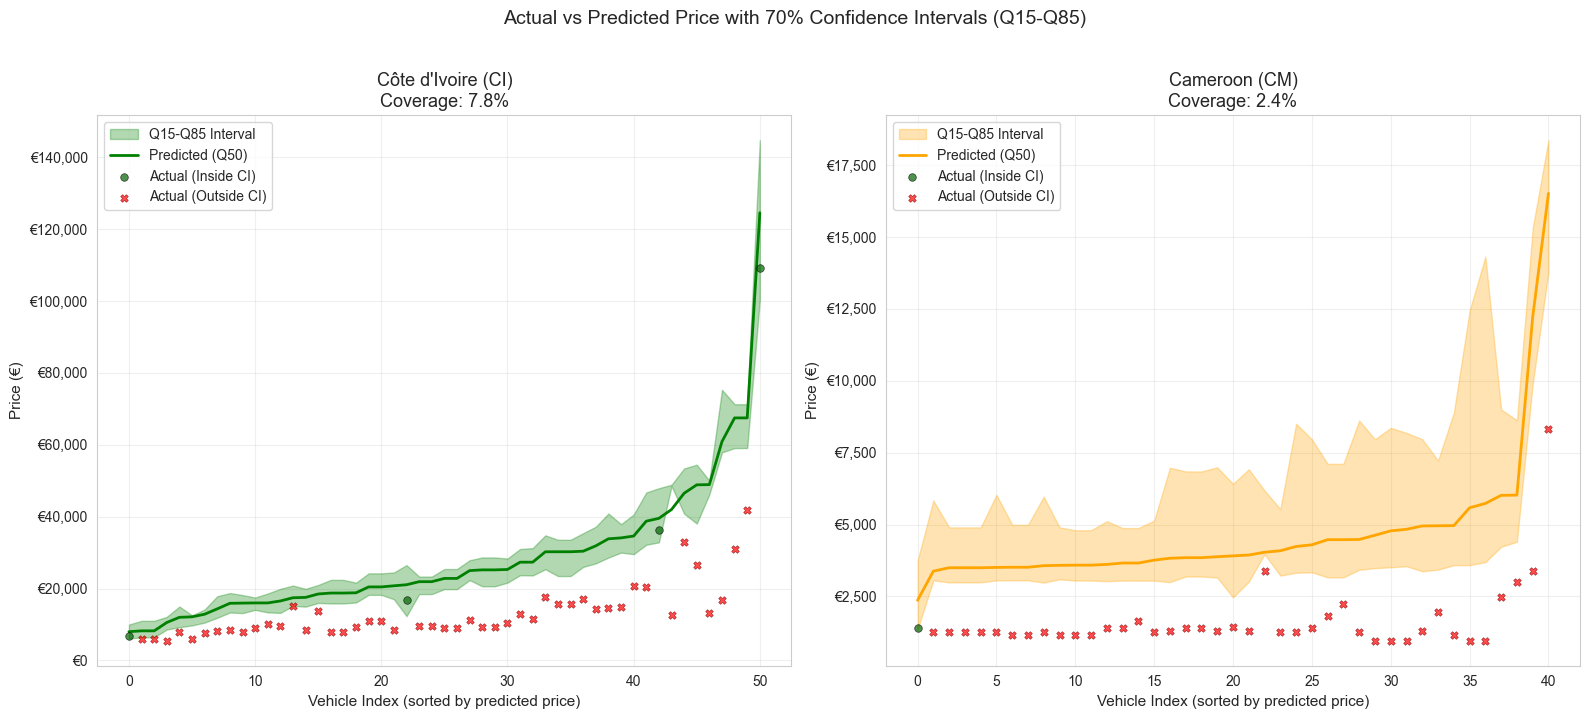

In [22]:
# %% Actual vs Predicted Price with Confidence Intervals
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Color palette
colors = {'CI': 'green', 'CM': 'orange'}

for idx, (country, df_results, ax) in enumerate([
    ('CI', df_ci_results, axes[0]),
    ('CM', df_cm_results, axes[1])
]):
    actual = df_results['actual_price_eur'].to_numpy()
    pred_q15 = df_results['pred_q15'].to_numpy()
    pred_q50 = df_results['pred_q50'].to_numpy()
    pred_q85 = df_results['pred_q85'].to_numpy()

    # Sort by predicted for cleaner visualization
    # Vehicle index is just sequential numbering (0, 1, 2, ...) after sorting by predicted price
    # This creates a smooth ascending curve in the visualization
    sort_idx = np.argsort(pred_q50)

    # Plot confidence interval band
    ax.fill_between(
        range(len(sort_idx)),
        pred_q15[sort_idx],
        pred_q85[sort_idx],
        alpha=0.3,
        color=colors[country],
        label='Q15-Q85 Interval'
    )

    # Plot Q50 prediction line
    ax.plot(
        range(len(sort_idx)),
        pred_q50[sort_idx],
        color=colors[country],
        linewidth=2,
        label='Predicted (Q50)'
    )

    # Separate points inside and outside confidence interval
    inside_ci = (actual >= pred_q15) & (actual <= pred_q85)
    outside_ci = ~inside_ci

    # Plot actual values - points inside CI
    if inside_ci.sum() > 0:
        ax.scatter(
            np.arange(len(sort_idx))[inside_ci[sort_idx]],
            actual[sort_idx][inside_ci[sort_idx]],
            color='darkgreen',
            s=30,
            alpha=0.7,
            label='Actual (Inside CI)',
            zorder=5,
            edgecolors='black',
            linewidths=0.5
        )

    # Plot actual values - points outside CI
    if outside_ci.sum() > 0:
        ax.scatter(
            np.arange(len(sort_idx))[outside_ci[sort_idx]],
            actual[sort_idx][outside_ci[sort_idx]],
            color='red',
            marker='X',
            s=30,
            alpha=0.7,
            label='Actual (Outside CI)',
            zorder=5,
            edgecolors='darkred',
            linewidths=0.5
        )

    # Calculate coverage
    coverage = np.mean((actual >= pred_q15) & (actual <= pred_q85)) * 100

    country_name = "Côte d'Ivoire" if country == 'CI' else "Cameroon"
    ax.set_title(f'{country_name} ({country})\nCoverage: {coverage:.1f}%', fontsize=13)
    ax.set_xlabel('Vehicle Index (sorted by predicted price)', fontsize=11)
    ax.set_ylabel('Price (€)', fontsize=11)

    # Format y-axis
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Price with 70% Confidence Intervals (Q15-Q85)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [23]:
(
    pl.concat([df_ci_results[['country', 'actual_price_eur', 'pred_q15', 'pred_q85']]
               , df_cm_results[['country', 'actual_price_eur', 'pred_q15', 'pred_q85']]])
    .with_columns(
        pl.col('actual_price_eur').is_between(pl.col('pred_q15'), pl.col('pred_q85')).alias('within_ci')
    )
    .group_by('country')
    .agg([
        pl.col('within_ci').sum().alias('count_within_ci'),
        pl.len().alias('total_vehicles'),
        (pl.col('within_ci').sum().cast(pl.Float64) / pl.len() * 100).round(1).alias('coverage_pct')
    ])
    .sort('country')
)

country,count_within_ci,total_vehicles,coverage_pct
str,u32,u32,f64
"""CI""",4,51,7.8
"""CM""",1,41,2.4


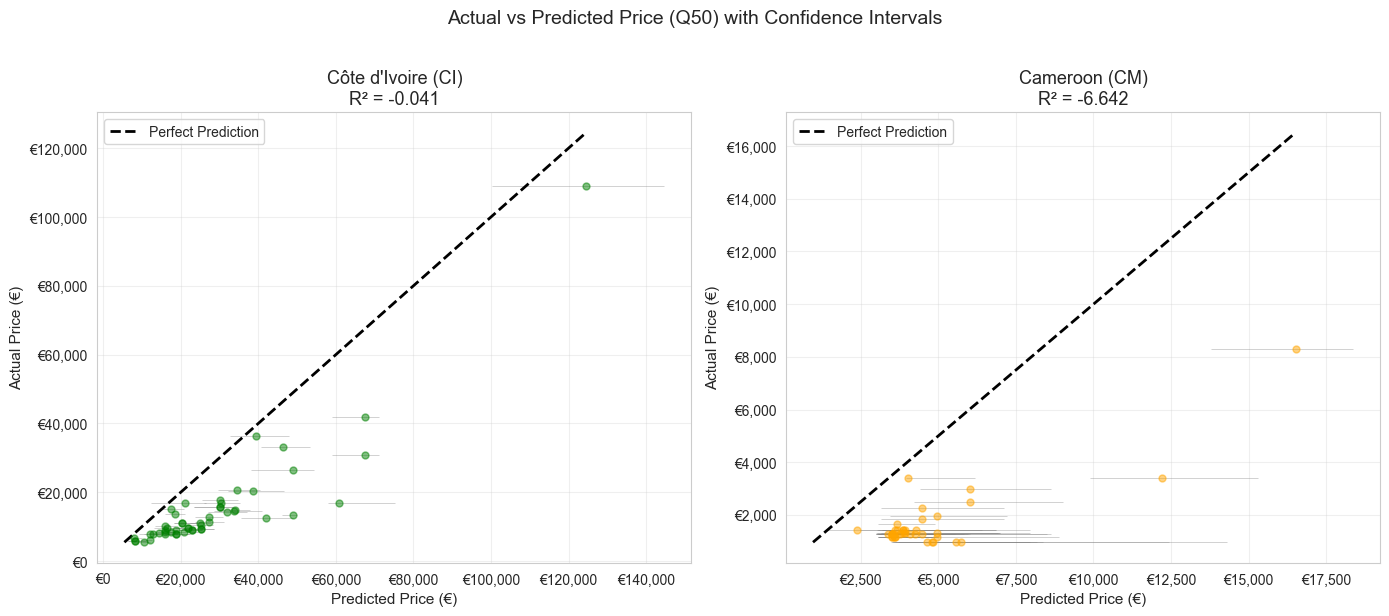

In [24]:
# %% Alternative: Scatter plot Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (country, df_results, ax) in enumerate([
    ('CI', df_ci_results, axes[0]),
    ('CM', df_cm_results, axes[1])
]):
    actual = df_results['actual_price_eur'].to_numpy()
    pred_q15 = df_results['pred_q15'].to_numpy()
    pred_q50 = df_results['pred_q50'].to_numpy()
    pred_q85 = df_results['pred_q85'].to_numpy()
    
    # Error bars for confidence interval
    # Use absolute values to prevent ValueError if quantiles are misordered
    lower_err = np.abs(pred_q50 - pred_q15)
    upper_err = np.abs(pred_q85 - pred_q50)
    
    # Scatter with error bars
    ax.errorbar(
        pred_q50, actual,
        xerr=[lower_err, upper_err],
        fmt='o',
        color=colors[country],
        alpha=0.5,
        markersize=5,
        ecolor='gray',
        elinewidth=0.5,
        capsize=0
    )
    
    # Perfect prediction line
    max_val = max(actual.max(), pred_q50.max())
    min_val = min(actual.min(), pred_q50.min())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')
    
    country_name = "Côte d'Ivoire" if country == 'CI' else "Cameroon"
    r2 = r2_score(actual, pred_q50)
    ax.set_title(f'{country_name} ({country})\nR² = {r2:.3f}', fontsize=13)
    ax.set_xlabel('Predicted Price (€)', fontsize=11)
    ax.set_ylabel('Actual Price (€)', fontsize=11)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Format axes
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))

plt.suptitle('Actual vs Predicted Price (Q50) with Confidence Intervals', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Visualization: Residuals vs Predicted Price

Analyze how residuals (errors) evolve with predicted price.

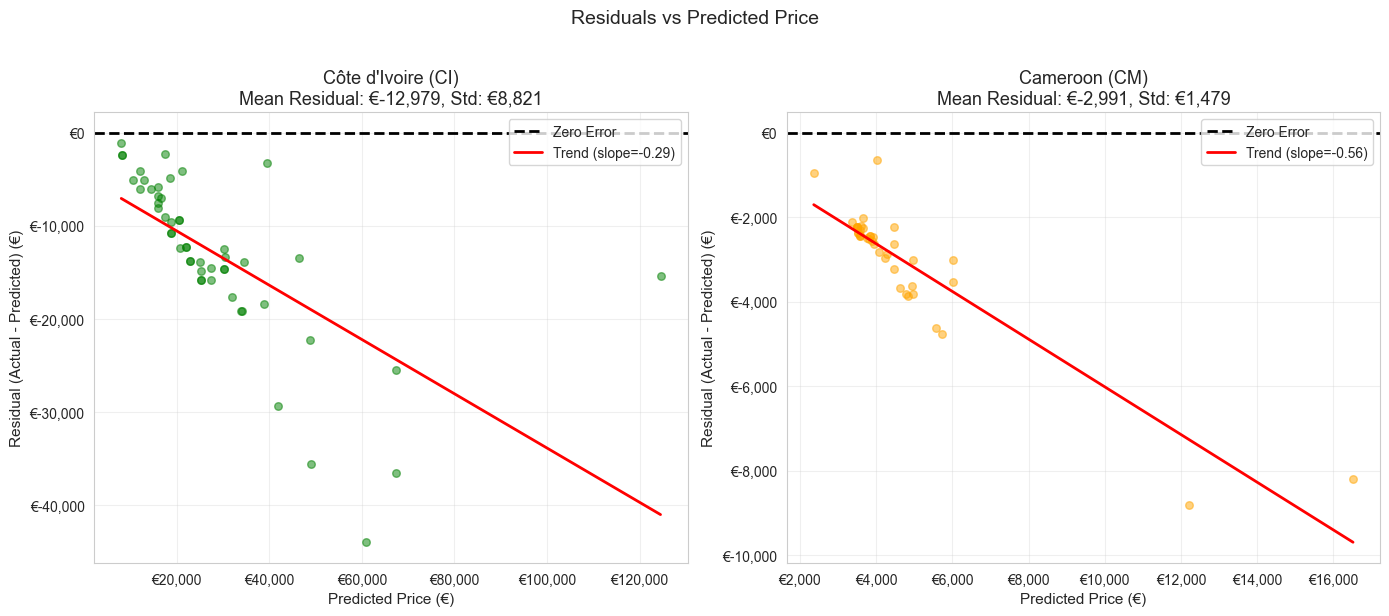

In [25]:
# %% Residuals vs Predicted Price
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (country, df_results, ax) in enumerate([
    ('CI', df_ci_results, axes[0]),
    ('CM', df_cm_results, axes[1])
]):
    pred_q50 = df_results['pred_q50'].to_numpy()
    residuals = df_results['residual'].to_numpy()
    
    # Scatter plot
    ax.scatter(pred_q50, residuals, alpha=0.5, color=colors[country], s=30)
    
    # Zero line
    ax.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Zero Error')
    
    # Add trend line
    z = np.polyfit(pred_q50, residuals, 1)
    p = np.poly1d(z)
    x_line = np.linspace(pred_q50.min(), pred_q50.max(), 100)
    ax.plot(x_line, p(x_line), 'r-', linewidth=2, label=f'Trend (slope={z[0]:.2f})')
    
    country_name = "Côte d'Ivoire" if country == 'CI' else "Cameroon"
    mean_residual = residuals.mean()
    std_residual = residuals.std()
    ax.set_title(f'{country_name} ({country})\nMean Residual: €{mean_residual:,.0f}, Std: €{std_residual:,.0f}', fontsize=13)
    ax.set_xlabel('Predicted Price (€)', fontsize=11)
    ax.set_ylabel('Residual (Actual - Predicted) (€)', fontsize=11)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Format x-axis
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))

plt.suptitle('Residuals vs Predicted Price', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Summary and Export

Final summary and optional data export.

In [26]:
# %% Summary
print("=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)

print("\n📊 Dataset Sizes:")
print(f"  Training data: {len(df):,} vehicles")
print(f"  Côte d'Ivoire (CI): {len(df_ci_results):,} vehicles")
print(f"  Cameroon (CM): {len(df_cm_results):,} vehicles")

print("\n📈 Model Performance:")
print(f"  {'Metric':<25} {'CI':>15} {'CM':>15}")
print(f"  {'-'*55}")
print(f"  {'MAE (€)':<25} {metrics_ci['MAE (€)']:>15,.0f} {metrics_cm['MAE (€)']:>15,.0f}")
print(f"  {'MAPE (%)':<25} {metrics_ci['MAPE (%)']:>15.1f} {metrics_cm['MAPE (%)']:>15.1f}")
print(f"  {'R²':<25} {metrics_ci['R²']:>15.3f} {metrics_cm['R²']:>15.3f}")
print(f"  {'Coverage Q15-Q85 (%)':<25} {metrics_ci['Coverage Q15-Q85 (%)']:>15.1f} {metrics_cm['Coverage Q15-Q85 (%)']:>15.1f}")

print("\n💡 Key Insights:")
if metrics_ci['MAE (€)'] < metrics_cm['MAE (€)']:
    print(f"  - Model performs better on CI data (lower MAE)")
else:
    print(f"  - Model performs better on CM data (lower MAE)")

for country, metrics in [('CI', metrics_ci), ('CM', metrics_cm)]:
    if metrics['Coverage Q15-Q85 (%)'] < 60:
        print(f"  ⚠️ {country}: Coverage below 60% - confidence intervals may be too narrow")
    elif metrics['Coverage Q15-Q85 (%)'] > 80:
        print(f"  ✓ {country}: Good coverage ({metrics['Coverage Q15-Q85 (%)']:.1f}%)")

print("\n✓ Evaluation complete!")

EVALUATION SUMMARY

📊 Dataset Sizes:
  Training data: 620,918 vehicles
  Côte d'Ivoire (CI): 51 vehicles
  Cameroon (CM): 41 vehicles

📈 Model Performance:
  Metric                                 CI              CM
  -------------------------------------------------------
  MAE (€)                            12,979           2,991
  MAPE (%)                            100.7           210.6
  R²                                 -0.041          -6.642
  Coverage Q15-Q85 (%)                  7.8             2.4

💡 Key Insights:
  - Model performs better on CM data (lower MAE)
  ⚠️ CI: Coverage below 60% - confidence intervals may be too narrow
  ⚠️ CM: Coverage below 60% - confidence intervals may be too narrow

✓ Evaluation complete!


## 11.5 Interactive Price Validation Visualization

Create detailed Plotly visualizations comparing declared prices against training distribution and model predictions.

Preparing validation data…
✓ CI: 51 vehicles  | brands: ['chevrolet', 'citroen', 'ford', 'honda', 'hyundai', 'jeep', 'kia', 'landrover', 'mazda', 'mercedesbenz', 'mitsubishi', 'nissan', 'peugeot', 'toyota']
✓ CM: 41 vehicles  | brands: ['ford', 'hyundai', 'landrover', 'mitsubishi', 'seat', 'toyota']
✓ CSVs saved to: /Users/brunobrumbrum/car_price_prediction/output
✓ Saved legend image: /Users/brunobrumbrum/car_price_prediction/output/validation_legend.png

PLOTTING — IVORY COAST (CI)
  → 'Chevrolet · Citroën · Peugeot · Ford': 6 vehicles, 4 brand(s)
       🟢 GREEN : 2
       🟠 ORANGE: 0
       🔴 RED   : 4


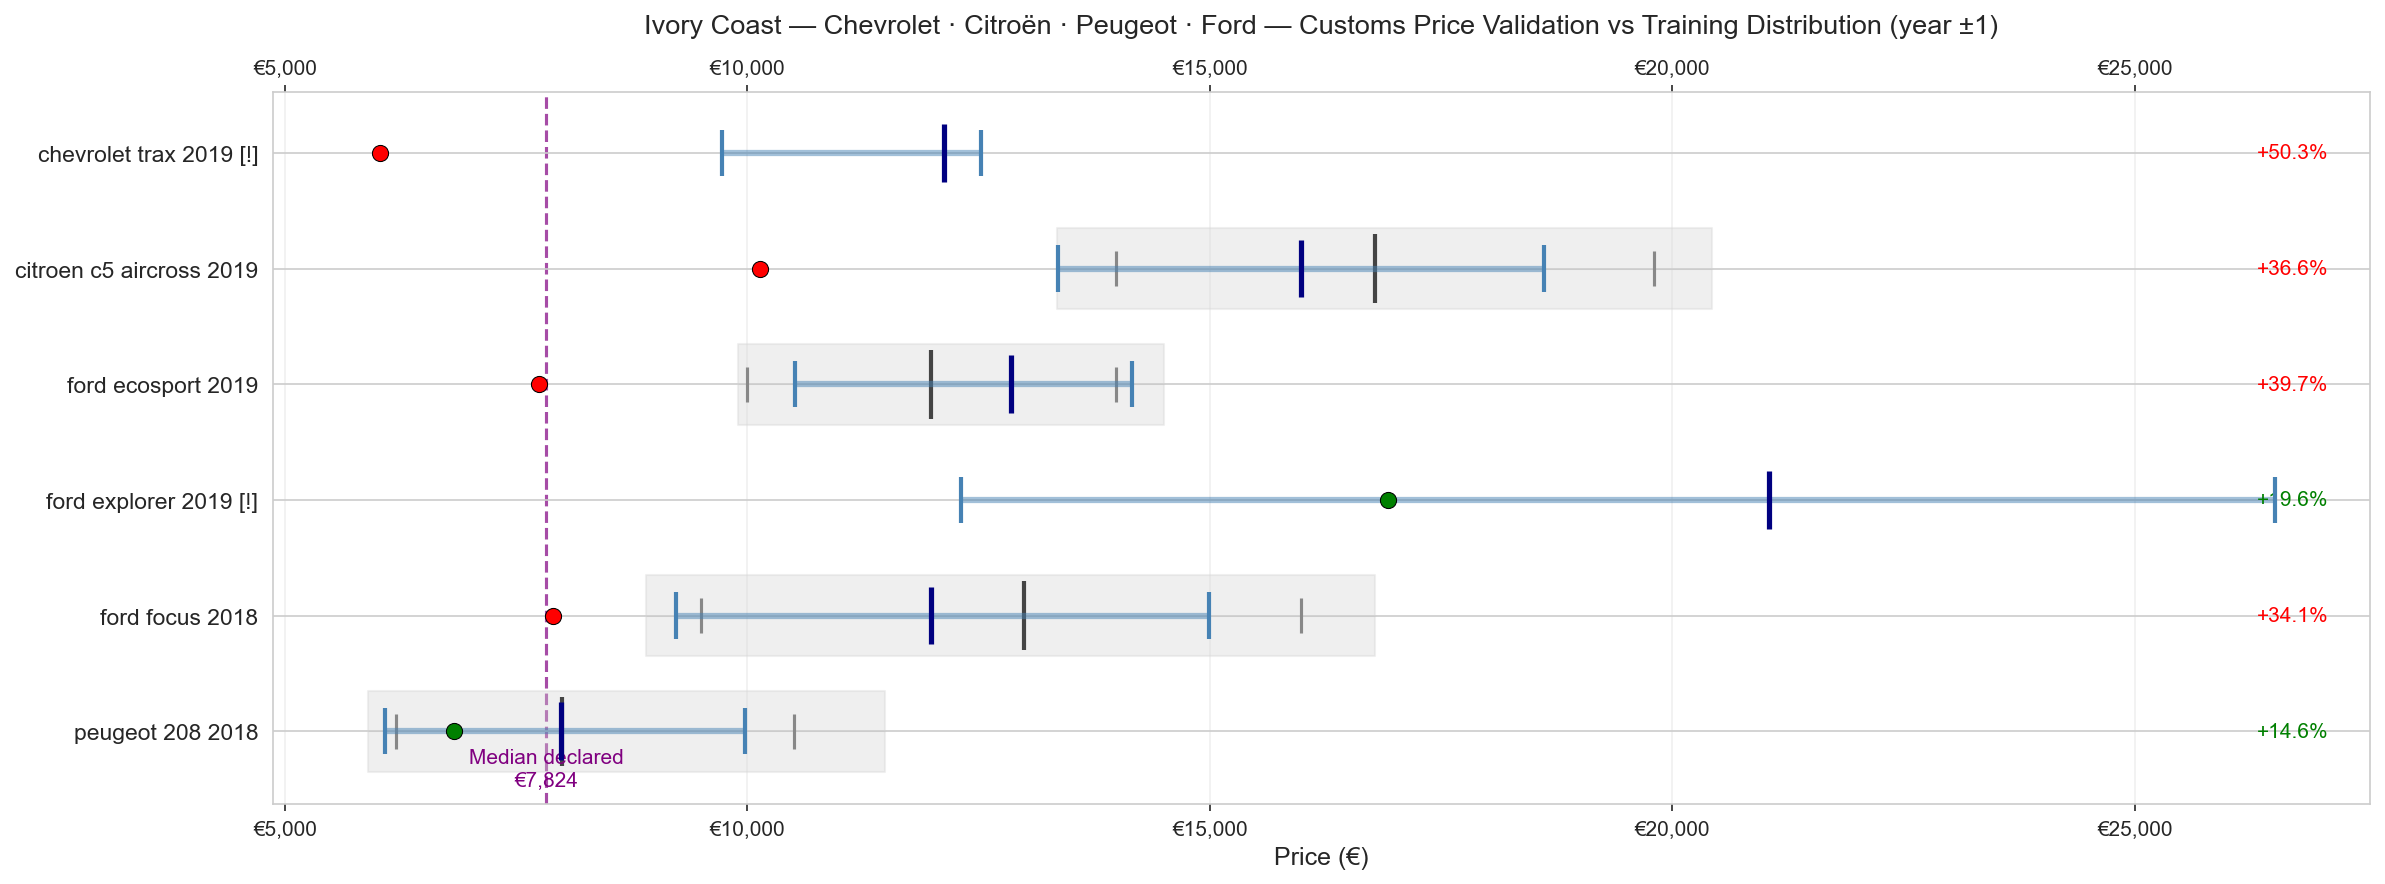

  → 'Honda · Hyundai': 10 vehicles, 2 brand(s)
       🟢 GREEN : 0
       🟠 ORANGE: 0
       🔴 RED   : 10


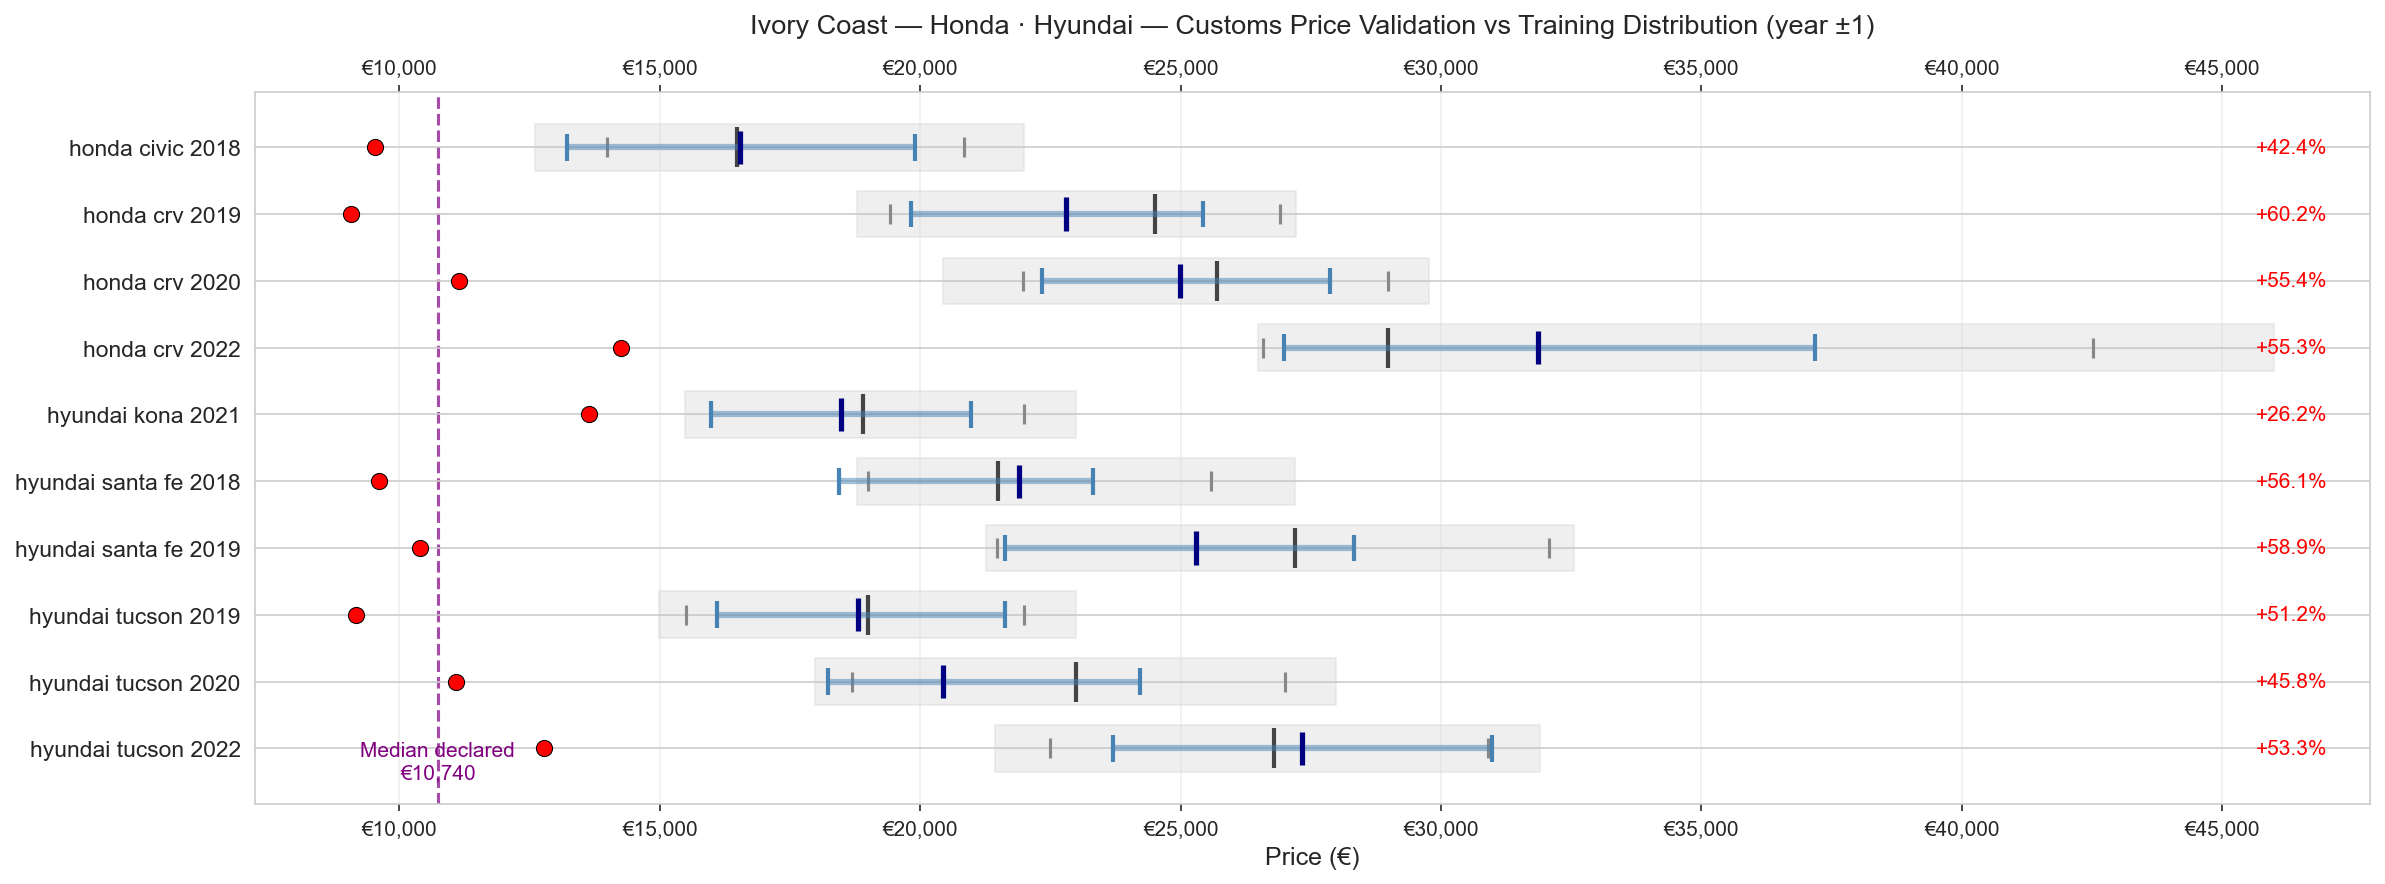

  → 'Jeep · Land Rover · Mercedes': 6 vehicles, 3 brand(s)
       🟢 GREEN : 2
       🟠 ORANGE: 1
       🔴 RED   : 3


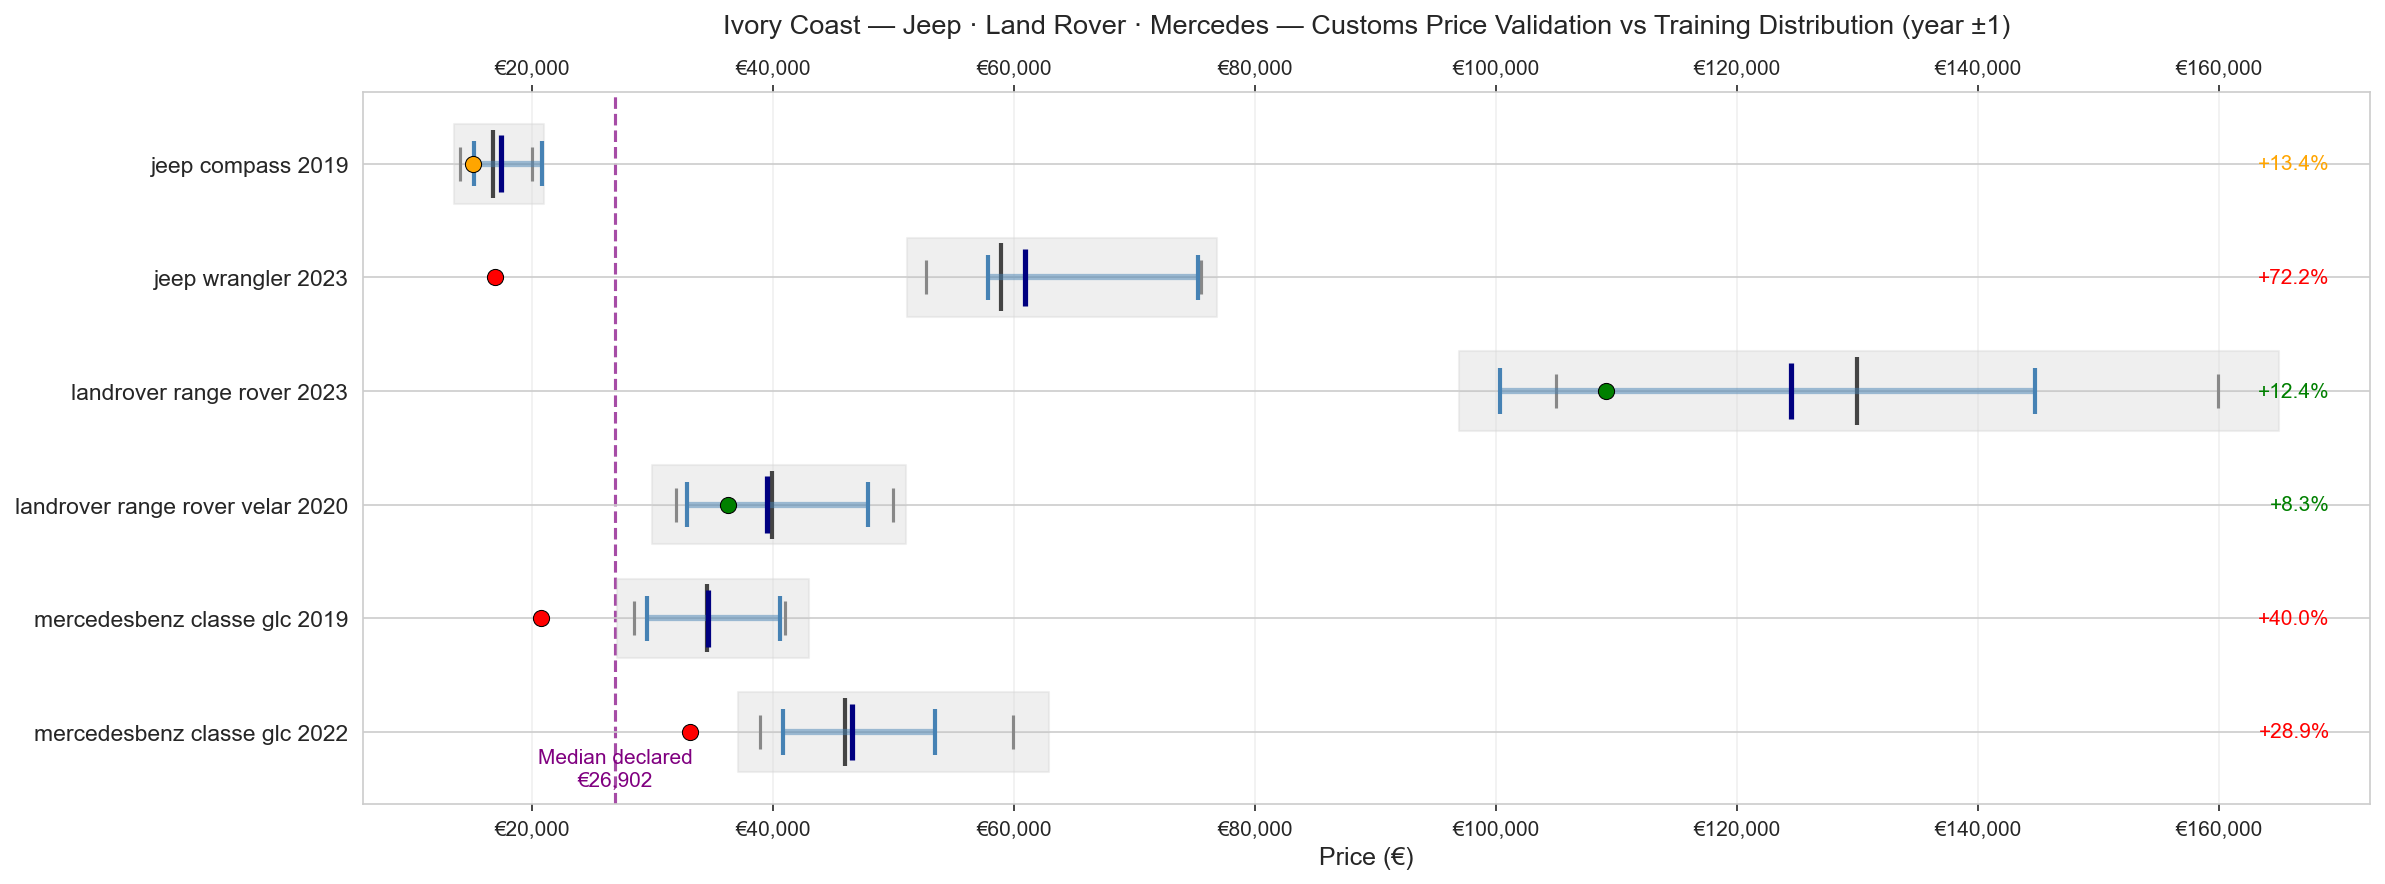

  → 'Kia · Mazda · Mitsubishi · Nissan': 10 vehicles, 4 brand(s)
       🟢 GREEN : 0
       🟠 ORANGE: 0
       🔴 RED   : 10


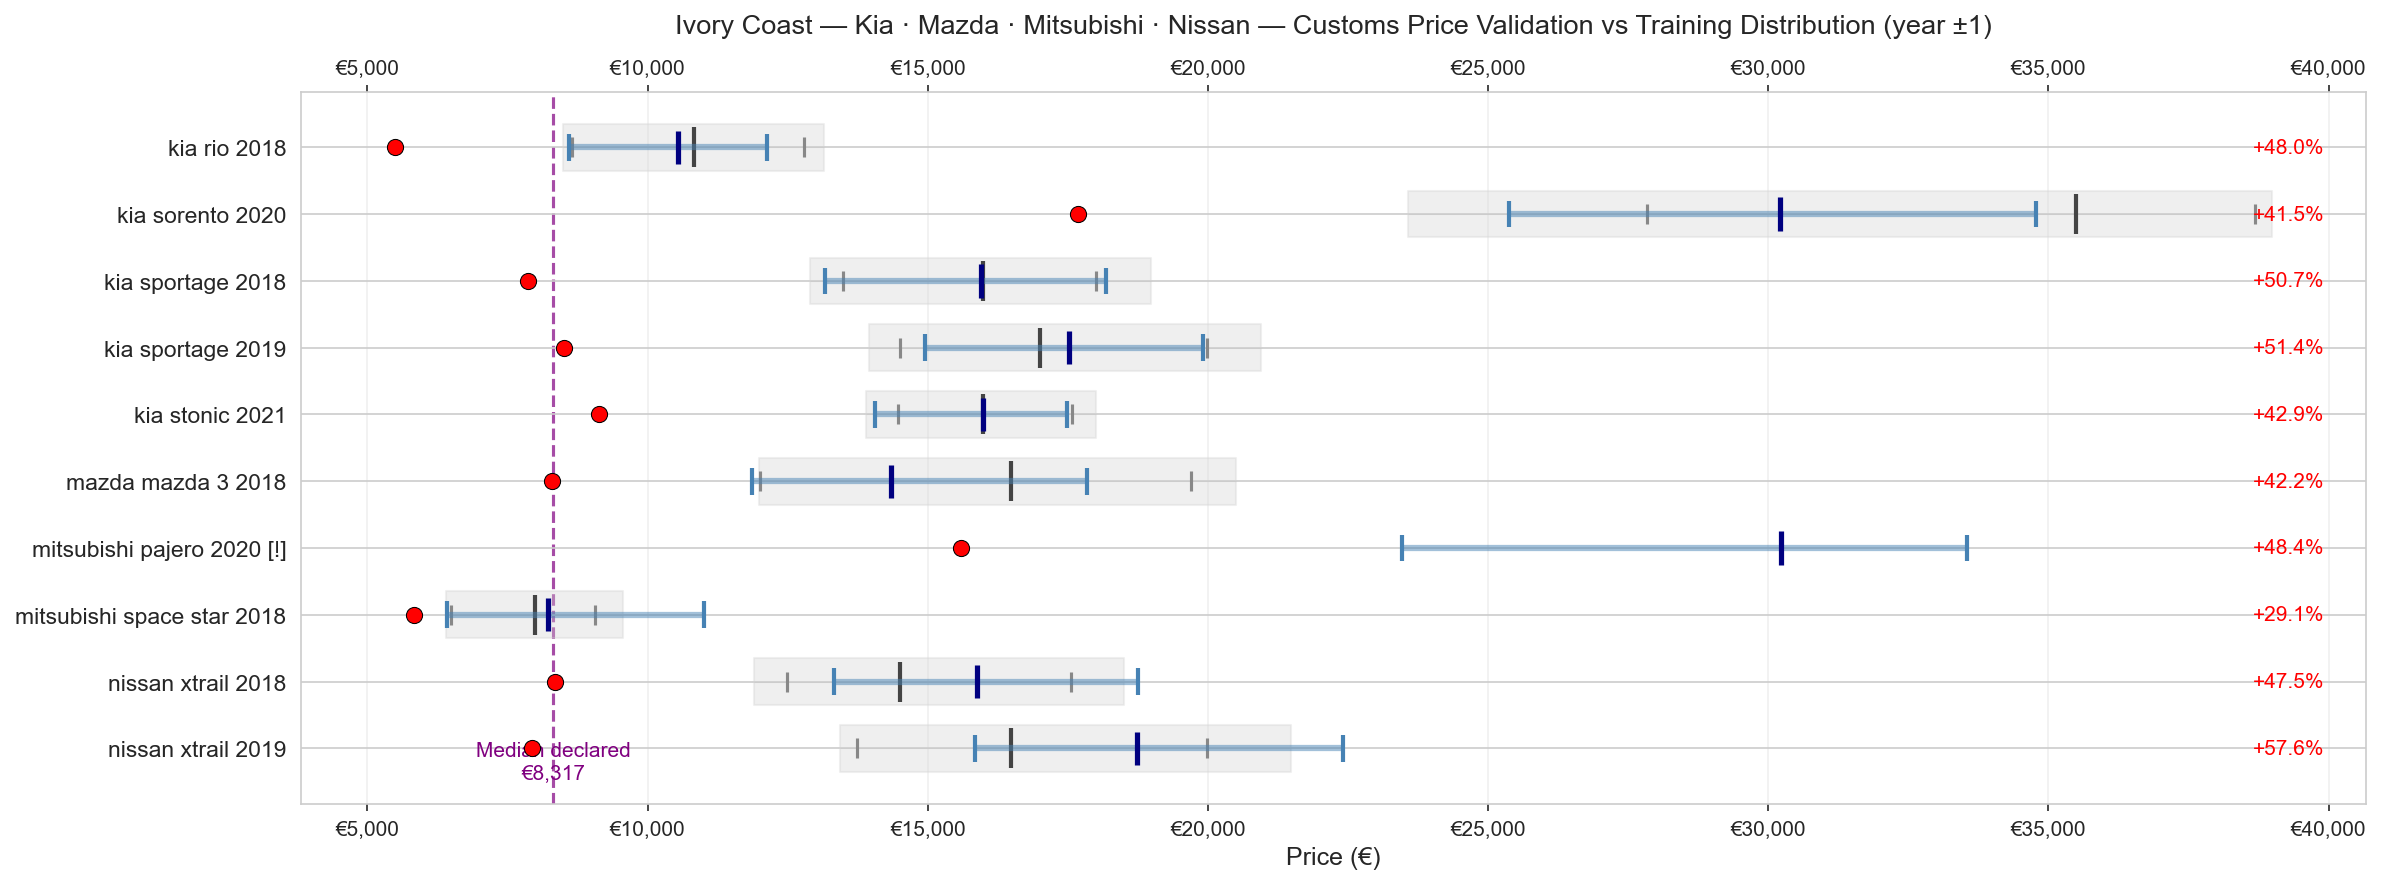

  → 'Toyota': 12 vehicles, 1 brand(s)
       🟢 GREEN : 0
       🟠 ORANGE: 0
       🔴 RED   : 12


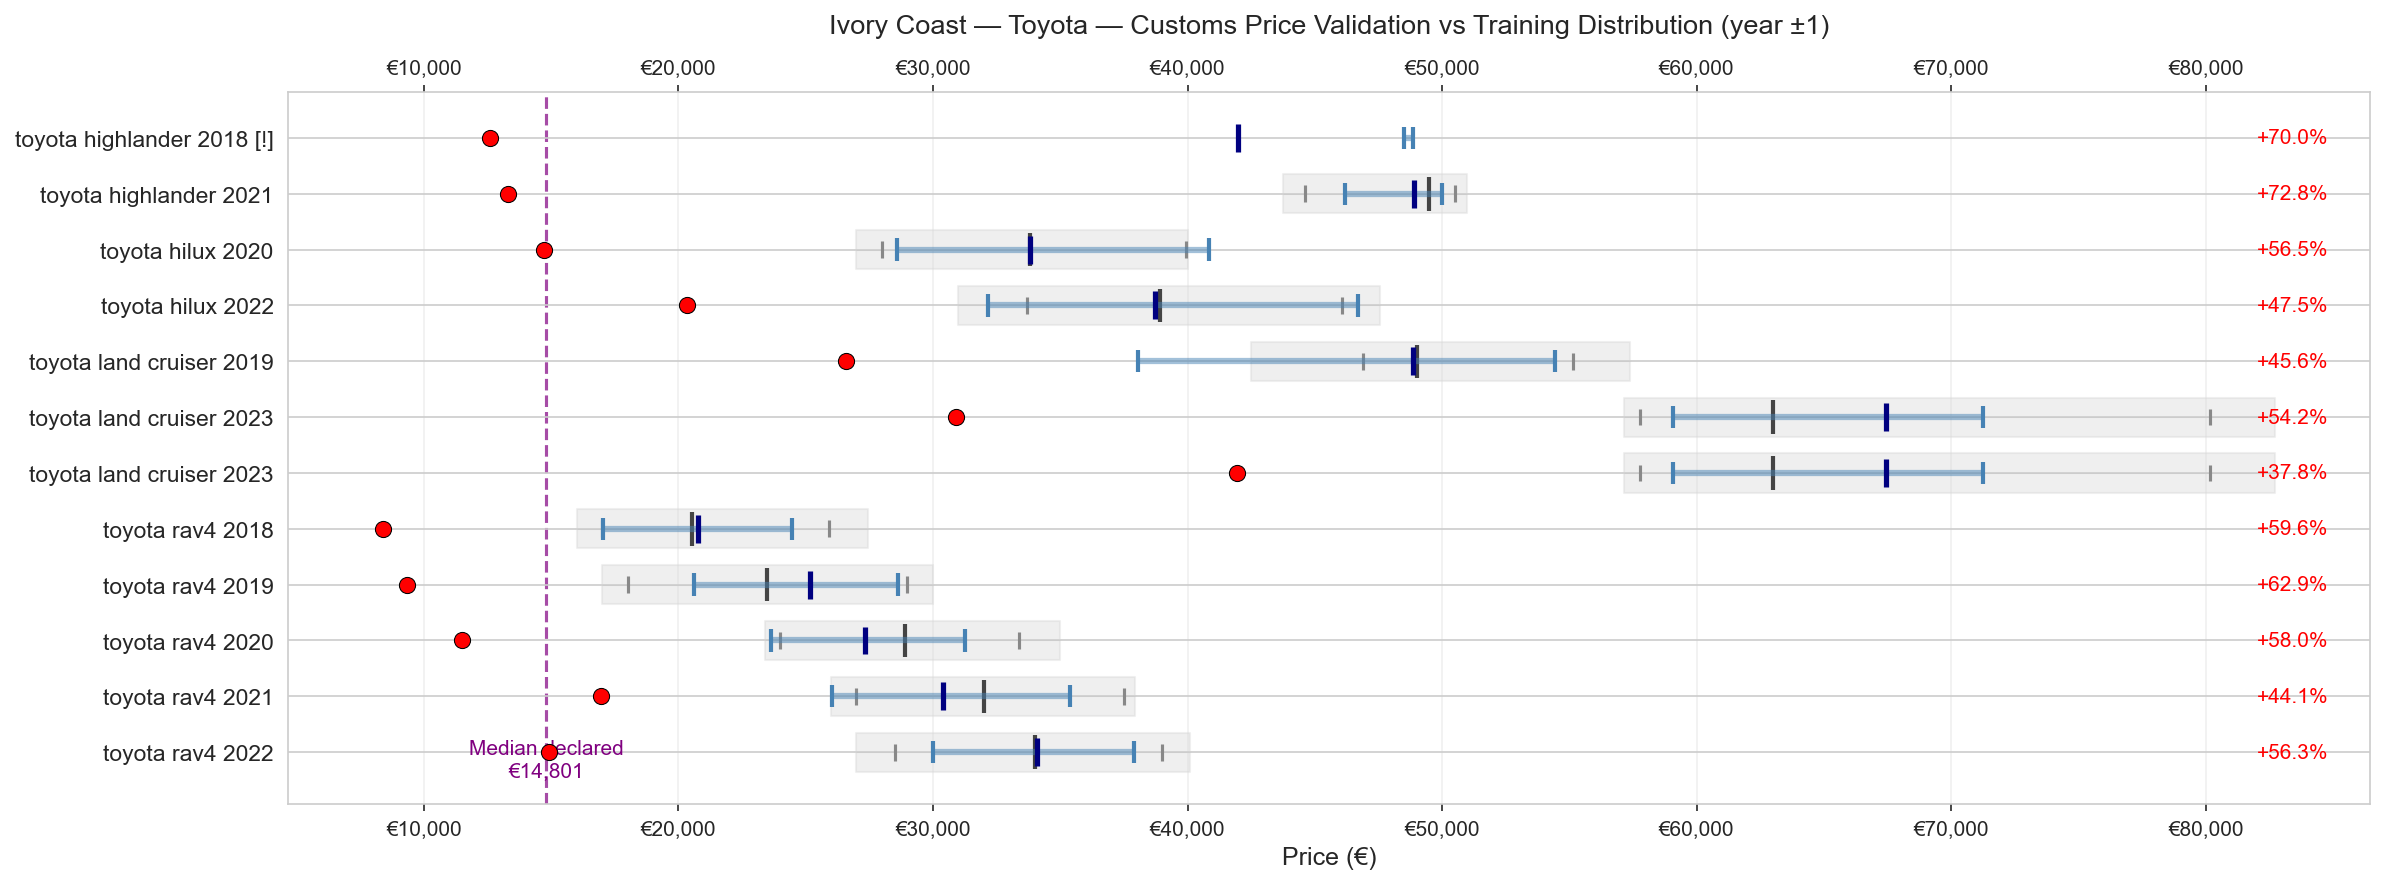


CM groups:
  'All Brands (excl. Toyota)': ['ford', 'hyundai', 'landrover', 'mitsubishi', 'seat']
  'Toyota': ['toyota']

PLOTTING — CAMEROON (CM)
  → 'All Brands (excl. Toyota)': 5 vehicles, 5 brand(s)
       🟢 GREEN : 1
       🟠 ORANGE: 0
       🔴 RED   : 4


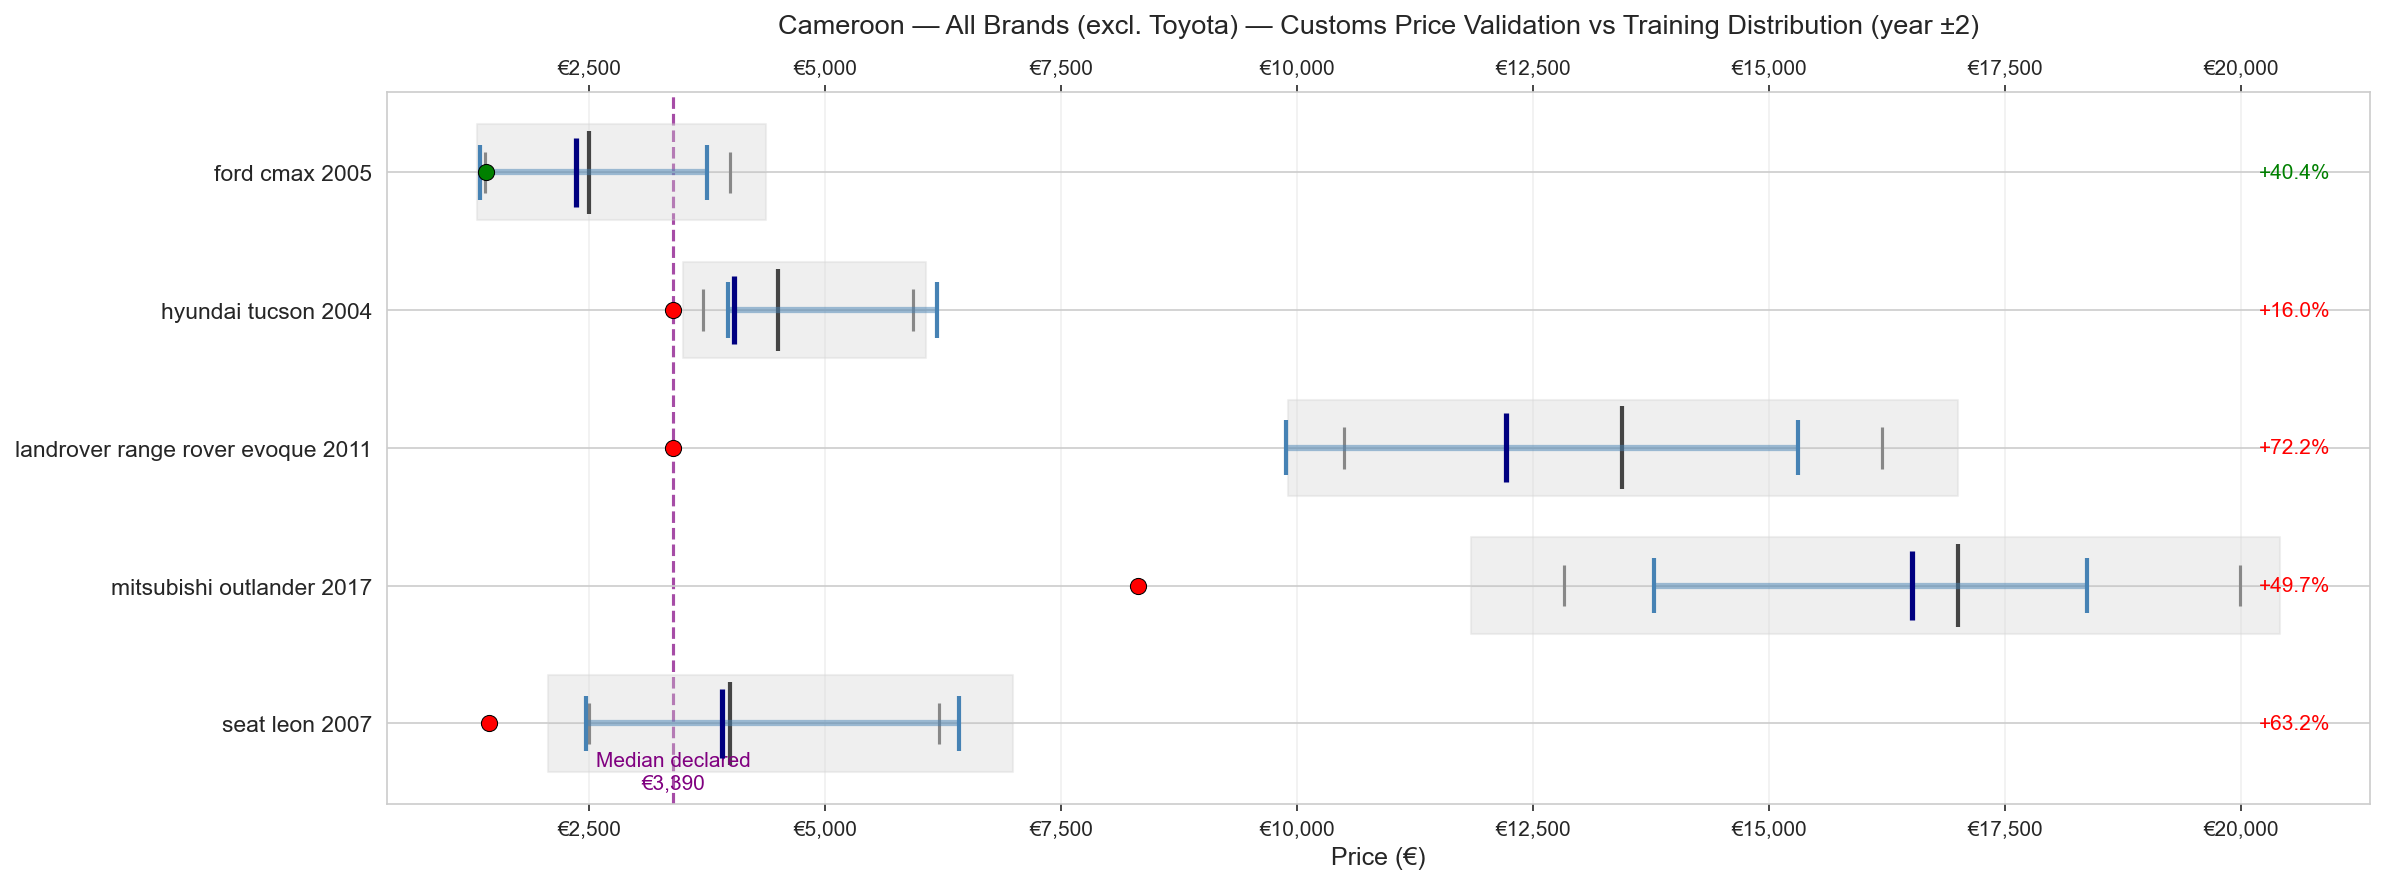

  → 'Toyota': 31 vehicles, 1 brand(s)
       🟢 GREEN : 0
       🟠 ORANGE: 0
       🔴 RED   : 31


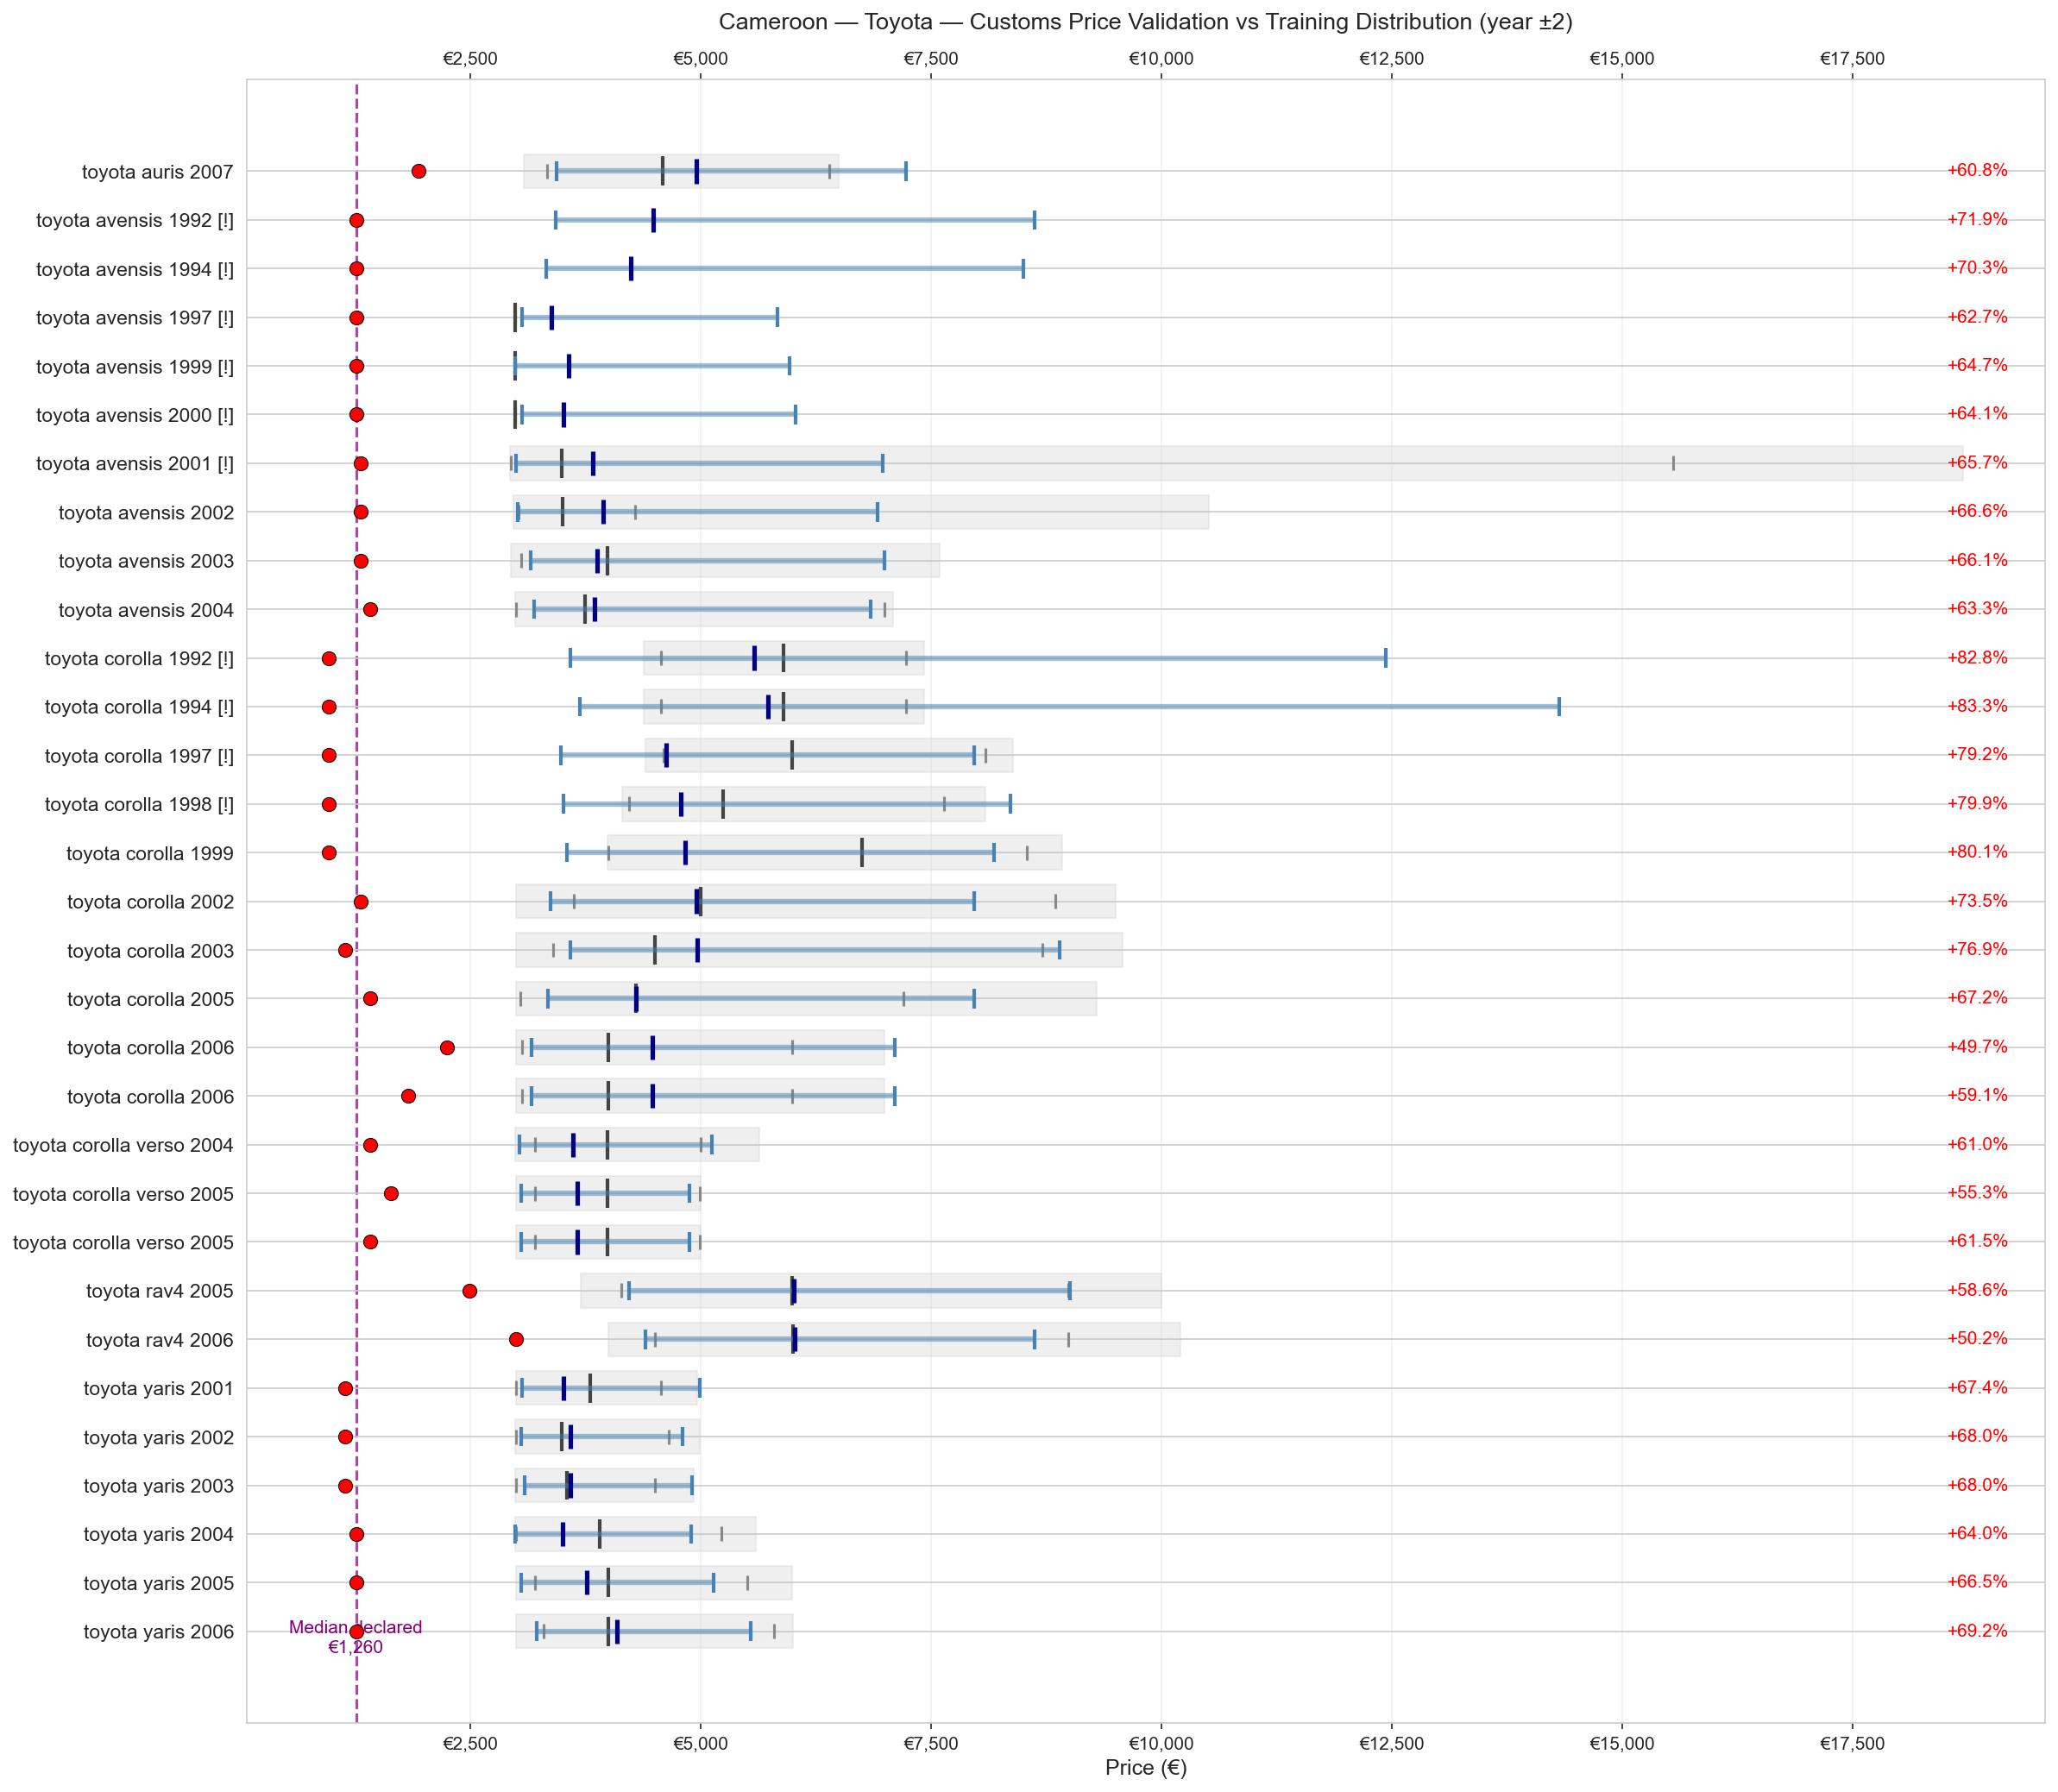


✓ VALIDATION COMPLETE

Outputs saved to: /Users/brunobrumbrum/car_price_prediction/output
  - validation_CI.csv
  - validation_CM.csv
  - validation_legend.png  ← add this to your slides


In [34]:
# %% Customs Price Validation Visualization (Matplotlib) — grouped plots, no inline legend
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
from pathlib import Path
from collections import OrderedDict

# Ensure output directory exists
output_dir = project_root / 'output'
output_dir.mkdir(exist_ok=True)


# ── Helper: warn label without emoji (⚠️ renders as empty box in matplotlib) ──
WARN_SUFFIX = ' [!]'


def prepare_validation_data(df_customs, df_training, country_code, year_flex=3):
    """
    Prepare validation data matching customs cars against training data.
    Matches on brand, model, year (±year_flex) as THREE independent columns.
    """
    results = []
    df_train_pd = df_training.to_pandas()

    for row in df_customs.iter_rows(named=True):
        brand          = row['brand']
        model          = row['model']
        year           = row['year']
        declared_price = row['actual_price_eur']
        pred_q15       = row['pred_q15']
        pred_q50       = row['pred_q50']
        pred_q85       = row['pred_q85']

        # Filter training data on THREE independent columns
        mask = (
            (df_train_pd['brand'] == brand) &
            (df_train_pd['model'] == model) &
            (df_train_pd['year'] >= year - year_flex) &
            (df_train_pd['year'] <= year + year_flex)
        )
        matched = df_train_pd[mask]
        training_sample_size = len(matched)

        if training_sample_size > 0:
            prices    = matched['price'].values
            train_p10 = float(np.percentile(prices, 10))
            train_q15 = float(np.percentile(prices, 15))
            train_q50 = float(np.percentile(prices, 50))
            train_q85 = float(np.percentile(prices, 85))
            train_p90 = float(np.percentile(prices, 90))
            has_training_data = True
        else:
            train_p10 = train_q15 = train_q50 = train_q85 = train_p90 = np.nan
            has_training_data = False

        gap_pct = (pred_q50 - declared_price) / pred_q50 * 100

        # ── Color tier logic ──────────────────────────────────────────────
        # GREEN  : declared inside prediction interval [pred_q15, pred_q85]
        # ORANGE : outside prediction interval BUT within training [P10, P90]
        #          (requires training data to be present)
        # RED    : outside training P10-P90 range entirely, OR no training data
        if pred_q15 <= declared_price <= pred_q85:
            color_tier = 'GREEN'
        elif has_training_data and (train_p10 <= declared_price <= train_p90):
            color_tier = 'ORANGE'
        else:
            color_tier = 'RED'

        results.append({
            'brand': brand, 'model': model, 'year': year,
            'declared_price': declared_price,
            'pred_q15': pred_q15, 'pred_q50': pred_q50, 'pred_q85': pred_q85,
            'train_p10': train_p10, 'train_q15': train_q15,
            'train_q50': train_q50, 'train_q85': train_q85, 'train_p90': train_p90,
            'gap_pct': gap_pct, 'color_tier': color_tier,
            'training_sample_size': training_sample_size,
            'has_training_data': has_training_data,
        })

    df_result = pd.DataFrame(results)
    df_result = df_result.sort_values(['brand', 'model', 'year']).reset_index(drop=True)
    return df_result


def create_validation_plot(df_subset, title, median_declared, year_flex=3):
    """
    Generic validation plot for any subset of validation data.
    - Y-axis: brand + model + year
    - Grey filled band between train_p10 and train_p90 (10th-90th percentile)
    - No legend (call save_legend_image separately)
    - [!] suffix instead of ⚠️ emoji (avoids empty-box rendering in matplotlib)
    """
    n_cars = len(df_subset)
    if n_cars == 0:
        print("    ⚠ Empty subset — skipping plot.")
        return None

    fig_height = max(6, n_cars * 0.45)
    fig, ax = plt.subplots(figsize=(16, fig_height), dpi=150)

    color_map = {'GREEN': 'green', 'ORANGE': 'orange', 'RED': 'red'}

    # Y-axis labels: brand + model + year (+ [!] if < 5 training samples)
    labels = []
    for _, row in df_subset.iterrows():
        label = f"{row['brand']} {row['model']} {int(row['year'])}"
        if row['training_sample_size'] < 5:
            label += WARN_SUFFIX
        labels.append(label)

    y_positions = np.arange(n_cars)

    for i, (_, row) in enumerate(df_subset.iterrows()):
        y = y_positions[i]

        # ── LAYER 1 — Training reference (skip silently if no data) ──────
        if row['has_training_data'] and not np.isnan(row['train_p10']):
            # Filled light-grey band between train_p10 and train_p90 (10th-90th percentile)
            ax.fill_betweenx(
                [y - 0.35, y + 0.35],
                row['train_p10'], row['train_p90'],
                color='lightgrey', alpha=0.35, zorder=1
            )
            # Thin border along the band
            ax.hlines(y, row['train_p10'], row['train_p90'],
                      colors='#cccccc', linewidth=0.5, zorder=1)
            # Vlines: Q15 & Q85 (short)
            ax.vlines(row['train_q15'], ymin=y - 0.15, ymax=y + 0.15,
                      color='#888888', linewidth=1.5, zorder=2)
            ax.vlines(row['train_q85'], ymin=y - 0.15, ymax=y + 0.15,
                      color='#888888', linewidth=1.5, zorder=2)
            # Vline: Q50 (tall, dark grey)
            ax.vlines(row['train_q50'], ymin=y - 0.30, ymax=y + 0.30,
                      color='#444444', linewidth=2.0, zorder=2)

        # ── LAYER 2 — Prediction interval (always shown) ────────────────
        ax.hlines(y, row['pred_q15'], row['pred_q85'],
                  colors='steelblue', linewidth=3, alpha=0.5, zorder=3)
        ax.vlines(row['pred_q15'], ymin=y - 0.20, ymax=y + 0.20,
                  color='steelblue', linewidth=2.0, zorder=4)
        ax.vlines(row['pred_q85'], ymin=y - 0.20, ymax=y + 0.20,
                  color='steelblue', linewidth=2.0, zorder=4)
        # Vline: Q50 (tall, navy)
        ax.vlines(row['pred_q50'], ymin=y - 0.25, ymax=y + 0.25,
                  color='navy', linewidth=2.5, zorder=4)

        # ── LAYER 3 — Declared price dot (always shown) ─────────────────
        dot_color = color_map[row['color_tier']]
        ax.scatter(row['declared_price'], y, color=dot_color,
                   s=60, zorder=5, edgecolors='black', linewidths=0.5)

    # Gap annotations (placed after xlim stabilises)
    ax.set_xlim(auto=True)
    x_min, x_max = ax.get_xlim()
    x_range = x_max - x_min

    for i, (_, row) in enumerate(df_subset.iterrows()):
        y = y_positions[i]
        gap_pct   = row['gap_pct']
        gap_sign  = '+' if gap_pct > 0 else ''
        dot_color = color_map[row['color_tier']]
        ax.annotate(
            f'{gap_sign}{gap_pct:.1f}%',
            xy=(x_max - x_range * 0.02, y),
            fontsize=10, color=dot_color, va='center', ha='right'
        )

    # Median declared price line (group-level)
    ax.axvline(x=median_declared, color='purple', linestyle='--',
               linewidth=1.5, alpha=0.7, zorder=0)
    ax.annotate(
        f'Median declared\n€{median_declared:,.0f}',
        xy=(median_declared, n_cars - 0.5),
        fontsize=10, color='purple', ha='center', va='bottom'
    )

    # Axes & layout
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel('Price (€)', fontsize=12)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='x', labeltop=True, labelbottom=True)
    ax.set_title(title, fontsize=13, pad=12)
    ax.grid(True, axis='x', alpha=0.3, zorder=0)
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return fig


def save_legend_image(output_dir):
    """Save a standalone legend PNG (no axes, no plot)."""
    fig, ax = plt.subplots(figsize=(9, 4), dpi=150)
    ax.axis('off')

    green_patch        = mpatches.Patch(color='green',     label='Inside prediction interval (pred_q15 to pred_q85)')
    orange_patch       = mpatches.Patch(color='orange',    label='Outside pred. interval but within training P10–P90')
    red_patch          = mpatches.Patch(color='red',       label='Outside training P10-P90 range or no training data')
    grey_band          = mpatches.Patch(color='lightgrey', alpha=0.5, label='Training range band (P10 to P90, excludes extremes)')
    blue_line          = mlines.Line2D([], [], color='steelblue', linewidth=3, alpha=0.5,
                                       label='Prediction interval (pred_q15 to pred_q85)')
    pred_q50_marker    = mlines.Line2D([], [], color='navy',    linewidth=2.5,
                                       label='Pred Q50 — tall navy vline')
    pred_q1585_marker  = mlines.Line2D([], [], color='steelblue', linewidth=2.0,
                                       label='Pred Q15/Q85 — blue vline end-caps')
    train_q50_marker   = mlines.Line2D([], [], color='#444444', linewidth=2.0,
                                       label='Train Q50 — tall dark-grey vline')
    train_q1585_marker = mlines.Line2D([], [], color='#888888', linewidth=1.5,
                                       label='Train Q15/Q85 — short grey vlines')
    warning_entry      = mlines.Line2D([], [], color='none', marker='None', linestyle='None',
                                       label='[!]  Fewer than 5 training samples for that combination')

    ax.legend(
        handles=[green_patch, orange_patch, red_patch, grey_band, blue_line,
                 pred_q50_marker, pred_q1585_marker,
                 train_q50_marker, train_q1585_marker, warning_entry],
        loc='center', fontsize=11, framealpha=0.95, ncol=1,
        title='Legend — Customs Price Validation', title_fontsize=12
    )

    plt.tight_layout()
    legend_path = output_dir / 'validation_legend.png'
    fig.savefig(legend_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved legend image: {legend_path}")


def plot_validation_groups(df_validation, country_code, country_name, brand_groups, year_flex=3):
    """
    Generate one plot per entry in brand_groups.

    Args:
        df_validation : pandas DataFrame from prepare_validation_data()
        brand_groups  : OrderedDict { group_label_str : [list_of_brand_strings] }
                        Brand strings must match the lowercase values in df_validation['brand'].
    Returns:
        dict { group_label : matplotlib Figure }
    """
    print(f"\n{'='*70}")
    print(f"PLOTTING — {country_name.upper()} ({country_code})")
    print(f"{'='*70}")

    figs = {}
    for group_label, brands in brand_groups.items():
        df_subset = df_validation[df_validation['brand'].isin(brands)].copy()
        if df_subset.empty:
            print(f"  ⚠ Skipping '{group_label}' — no vehicles found (check brand name spelling)")
            continue

        n_cars   = len(df_subset)
        n_brands = df_subset['brand'].nunique()
        print(f"  → '{group_label}': {n_cars} vehicles, {n_brands} brand(s)")
        for tier, emoji in [('GREEN', '🟢'), ('ORANGE', '🟠'), ('RED', '🔴')]:
            n = (df_subset['color_tier'] == tier).sum()
            print(f"       {emoji} {tier:<6}: {n}")

        title = (
            f"{country_name} — {group_label} — "
            f"Customs Price Validation vs Training Distribution (year ±{year_flex})"
        )
        median_group = df_subset['declared_price'].median()
        fig = create_validation_plot(df_subset, title, median_group, year_flex=year_flex)
        figs[group_label] = fig

    return figs


# ============================================================
# PREPARE VALIDATION DATA FOR BOTH COUNTRIES
# ============================================================

print("Preparing validation data…")

df_validation_ci = prepare_validation_data(df_ci_results, df, 'CI', year_flex=1)
print(f"✓ CI: {len(df_validation_ci)} vehicles  "
      f"| brands: {sorted(df_validation_ci['brand'].unique())}")

df_validation_cm = prepare_validation_data(df_cm_results, df, 'CM', year_flex=2)
print(f"✓ CM: {len(df_validation_cm)} vehicles  "
      f"| brands: {sorted(df_validation_cm['brand'].unique())}")

# Save CSVs
csv_cols = [
    'brand', 'model', 'year', 'declared_price',
    'pred_q15', 'pred_q50', 'pred_q85',
    'train_p10', 'train_q15', 'train_q50', 'train_q85', 'train_p90',
    'gap_pct', 'color_tier', 'training_sample_size'
]
df_validation_ci[csv_cols].to_csv(output_dir / 'validation_CI.csv', index=False)
df_validation_cm[csv_cols].to_csv(output_dir / 'validation_CM.csv', index=False)
print(f"✓ CSVs saved to: {output_dir}")

# Save standalone legend image (shared by all plots)
save_legend_image(output_dir)


# ============================================================
# IVORY COAST — EXPLICIT BRAND GROUPINGS
# ============================================================
# Tip: run `sorted(df_validation_ci['brand'].unique())` to see exact brand strings.

ci_brand_groups = OrderedDict([
    ('Chevrolet · Citroën · Peugeot · Ford',
        ['chevrolet', 'citroen', 'citroën', 'peugeot', 'ford']),
    ('Honda · Hyundai',
        ['honda', 'hyundai']),
    ('Jeep · Land Rover · Mercedes',
        ['jeep', 'landrover', 'mercedesbenz', 'mercedes', 'mercedes-benz']),
    ('Kia · Mazda · Mitsubishi · Nissan',
        ['kia', 'mazda', 'mitsubishi', 'nissan']),
    ('Toyota',
        ['toyota']),
])

figs_ci = plot_validation_groups(
    df_validation_ci[df_validation_ci.duplicated() == False], 'CI', 'Ivory Coast', ci_brand_groups, year_flex=1
)


# ============================================================
# CAMEROON — BRAND GROUPINGS (dynamic: all except Toyota, then Toyota)
# ============================================================

all_cm_brands    = sorted(df_validation_cm['brand'].unique())
cm_non_toyota    = [b for b in all_cm_brands if b != 'toyota']
cm_brand_groups  = OrderedDict()

if cm_non_toyota:
    cm_brand_groups['All Brands (excl. Toyota)'] = cm_non_toyota
if 'toyota' in all_cm_brands:
    cm_brand_groups['Toyota'] = ['toyota']

print(f"\nCM groups:")
for lbl, brands in cm_brand_groups.items():
    print(f"  '{lbl}': {brands}")

figs_cm = plot_validation_groups(
    df_validation_cm[df_validation_cm.duplicated() == False], 'CM', 'Cameroon', cm_brand_groups, year_flex=2
)


# ============================================================
print("\n" + "=" * 70)
print("✓ VALIDATION COMPLETE")
print("=" * 70)
print(f"\nOutputs saved to: {output_dir}")
print(f"  - validation_CI.csv")
print(f"  - validation_CM.csv")
print(f"  - validation_legend.png  ← add this to your slides")

In [35]:
# %% Descriptive Statistics: Distance from Prediction & Confidence Interval
print("=" * 70)
print("UNDERVALUATION ANALYSIS — DECLARED vs PREDICTED")
print("=" * 70)

def compute_undervaluation_stats(df_val, country_name):
    """
    Compute undervaluation metrics for a validation DataFrame.
    All gaps are expressed as (predicted − declared), so positive = undervalued.
    """
    d = df_val.copy()

    # ── Absolute gaps (€) ──
    d['gap_q50_eur'] = d['pred_q50'] - d['declared_price']         # vs median prediction
    d['gap_q15_eur'] = d['pred_q15'] - d['declared_price']         # vs lower CI bound

    # ── Percentage gaps (% of prediction) ──
    d['gap_q50_pct'] = d['gap_q50_eur'] / d['pred_q50'] * 100
    d['gap_q15_pct'] = d['gap_q15_eur'] / d['pred_q15'] * 100

    # ── Summary table ──
    metrics = {}
    for label, col_eur, col_pct in [
        ('Gap from Q50 (median prediction)', 'gap_q50_eur', 'gap_q50_pct'),
        ('Gap from Q15 (lower CI bound)',    'gap_q15_eur', 'gap_q15_pct'),
    ]:
        metrics[label] = {
            'Mean (€)':    d[col_eur].mean(),
            'Median (€)':  d[col_eur].median(),
            'Std (€)':     d[col_eur].std(),
            'Min (€)':     d[col_eur].min(),
            'Max (€)':     d[col_eur].max(),
            'Mean (%)':    d[col_pct].mean(),
            'Median (%)':  d[col_pct].median(),
        }

    df_stats = pd.DataFrame(metrics).T
    df_stats.index.name = 'Metric'

    # ── Severity distribution ──
    n = len(d)
    below_q15 = (d['declared_price'] < d['pred_q15']).sum()
    between_q15_q50 = ((d['declared_price'] >= d['pred_q15']) &
                       (d['declared_price'] < d['pred_q50'])).sum()
    between_q50_q85 = ((d['declared_price'] >= d['pred_q50']) &
                       (d['declared_price'] <= d['pred_q85'])).sum()
    above_q85 = (d['declared_price'] > d['pred_q85']).sum()

    severity = pd.DataFrame({
        'Zone': [
            'Below Q15 (strongly undervalued)',
            'Q15 – Q50 (moderately undervalued)',
            'Q50 – Q85 (within upper half of CI)',
            'Above Q85 (overvalued vs prediction)',
        ],
        'Count': [below_q15, between_q15_q50, between_q50_q85, above_q85],
        '%': [below_q15/n*100, between_q15_q50/n*100, between_q50_q85/n*100, above_q85/n*100],
    })

    return d, df_stats, severity


# ── Côte d'Ivoire ──
print("\n🇨🇮  CÔTE D'IVOIRE (CI) — year ±1")
print("-" * 70)
df_ci_gaps, ci_stats, ci_severity = compute_undervaluation_stats(df_validation_ci, 'CI')
display(ci_stats.round(1))
print("\nSeverity distribution:")
display(ci_severity.round(1))

# ── Cameroon ──
print("\n🇨🇲  CAMEROON (CM) — year ±2")
print("-" * 70)
df_cm_gaps, cm_stats, cm_severity = compute_undervaluation_stats(df_validation_cm, 'CM')
display(cm_stats.round(1))
print("\nSeverity distribution:")
display(cm_severity.round(1))

# ── Side-by-side comparison ──
print("\n" + "=" * 70)
print("SIDE-BY-SIDE COMPARISON")
print("=" * 70)

comparison = pd.DataFrame({
    'Metric': [
        'Avg gap from Q50 (€)',
        'Median gap from Q50 (€)',
        'Avg gap from Q50 (%)',
        'Median gap from Q50 (%)',
        'Avg gap from Q15 (€)',
        'Median gap from Q15 (€)',
        'Avg gap from Q15 (%)',
        'Median gap from Q15 (%)',
        '% vehicles below Q15',
        '% vehicles below Q50',
    ],
    'Côte d\'Ivoire': [
        ci_stats.loc['Gap from Q50 (median prediction)', 'Mean (€)'],
        ci_stats.loc['Gap from Q50 (median prediction)', 'Median (€)'],
        ci_stats.loc['Gap from Q50 (median prediction)', 'Mean (%)'],
        ci_stats.loc['Gap from Q50 (median prediction)', 'Median (%)'],
        ci_stats.loc['Gap from Q15 (lower CI bound)', 'Mean (€)'],
        ci_stats.loc['Gap from Q15 (lower CI bound)', 'Median (€)'],
        ci_stats.loc['Gap from Q15 (lower CI bound)', 'Mean (%)'],
        ci_stats.loc['Gap from Q15 (lower CI bound)', 'Median (%)'],
        ci_severity.iloc[0]['%'],
        ci_severity.iloc[0]['%'] + ci_severity.iloc[1]['%'],
    ],
    'Cameroon': [
        cm_stats.loc['Gap from Q50 (median prediction)', 'Mean (€)'],
        cm_stats.loc['Gap from Q50 (median prediction)', 'Median (€)'],
        cm_stats.loc['Gap from Q50 (median prediction)', 'Mean (%)'],
        cm_stats.loc['Gap from Q50 (median prediction)', 'Median (%)'],
        cm_stats.loc['Gap from Q15 (lower CI bound)', 'Mean (€)'],
        cm_stats.loc['Gap from Q15 (lower CI bound)', 'Median (€)'],
        cm_stats.loc['Gap from Q15 (lower CI bound)', 'Mean (%)'],
        cm_stats.loc['Gap from Q15 (lower CI bound)', 'Median (%)'],
        cm_severity.iloc[0]['%'],
        cm_severity.iloc[0]['%'] + cm_severity.iloc[1]['%'],
    ],
})
display(comparison.round(1))


UNDERVALUATION ANALYSIS — DECLARED vs PREDICTED

🇨🇮  CÔTE D'IVOIRE (CI) — year ±1
----------------------------------------------------------------------


,Mean (€),Median (€),Std (€),Min (€),Max (€),Mean (%),Median (%)
Metric,,,,,,,
Gap from Q50 (median prediction),12979.0,12364.0,8908.4,1163.5,43958.6,46.3,48.4
Gap from Q15 (lower CI bound),8844.0,7857.3,9182.3,-8755.3,40949.5,35.1,38.1



Severity distribution:


,Zone,Count,%
0,Below Q15 (strongly undervalued),47,92.2
1,Q15 – Q50 (moderately undervalued),4,7.8
2,Q50 – Q85 (within upper half of CI),0,0.0
3,Above Q85 (overvalued vs prediction),0,0.0



🇨🇲  CAMEROON (CM) — year ±2
----------------------------------------------------------------------


,Mean (€),Median (€),Std (€),Min (€),Max (€),Mean (%),Median (%)
Metric,,,,,,,
Gap from Q50 (median prediction),2991.1,2501.0,1497.2,645.9,8822.2,64.5,65.7
Gap from Q15 (lower CI bound),1984.1,1796.8,1063.0,-60.6,6494.1,54.6,57.8



Severity distribution:


,Zone,Count,%
0,Below Q15 (strongly undervalued),40,97.6
1,Q15 – Q50 (moderately undervalued),1,2.4
2,Q50 – Q85 (within upper half of CI),0,0.0
3,Above Q85 (overvalued vs prediction),0,0.0



SIDE-BY-SIDE COMPARISON


,Metric,Côte d'Ivoire,Cameroon
0,Avg gap from Q50 (€),12979.0,2991.1
1,Median gap from Q50 (€),12364.0,2501.0
2,Avg gap from Q50 (%),46.3,64.5
3,Median gap from Q50 (%),48.4,65.7
4,Avg gap from Q15 (€),8844.0,1984.1
5,Median gap from Q15 (€),7857.3,1796.8
6,Avg gap from Q15 (%),35.1,54.6
7,Median gap from Q15 (%),38.1,57.8
8,% vehicles below Q15,92.2,97.6
9,% vehicles below Q50,100.0,100.0


In [ ]:
# %% Optional: Export Results
# Uncomment to export combined results to CSV

# output_path = project_root / 'data' / 'processed' / 'customs_predictions.csv'
# df_combined.write_csv(output_path)
# print(f"✓ Results exported to: {output_path}")